#### Initialization

In [15]:
library(repr)
library(tidyverse)
library(gtsummary)
library(broom)
library(broom.mixed)
library(gt)
library(ggprism)
library(marginaleffects)
library(ggeffects)

In [16]:
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)
options(bitmapType = 'cairo')
library(showtext)
font_add_google("Lato", "lato")
font_add_google(name = "Roboto", family = "roboto")
showtext_opts(dpi = 300)
showtext_auto()

#### Dwell Time Analysis

In [17]:
df <- read_csv("glaucoma_io_group_gaze.csv")
vf_df <- read_csv("vr_navigation_westbrueck_vf_data.csv")
df <- df |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        PID = factor(PID)
    ) |>
    rename(
        building_location = inside,
        group = category
    )

Rows: 1353 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (4): PID, inside, GroupCount, median_clusterDuration

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 18 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): med_id, group, gender, birth, measurement, comments
dbl (12): vr_id, age, MD_right, MD_left, MD_bin, pRFNL_right, pRFNL_left, IO...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [12]:
# df |> ggplot(aes(x = group, y = median_clusterDuration, color = building_location)) +
#  geom_point(position = position_dodge(0.4)) +
#  theme_minimal()
# ERROR DETECTED in the PIPELINE FROM MATLAB
# relabel done with the vf data
df <- df %>% mutate(
    group = factor(ifelse(PID %in% c(2006,2007,2013,2014,2021,2020,2025,5005,5006), "glaucoma", "control"))
)

[1] 0.4212926

[1] 0.3490451

Warning message:
“Removed 83 rows containing non-finite outside the scale range
(`stat_density()`).”


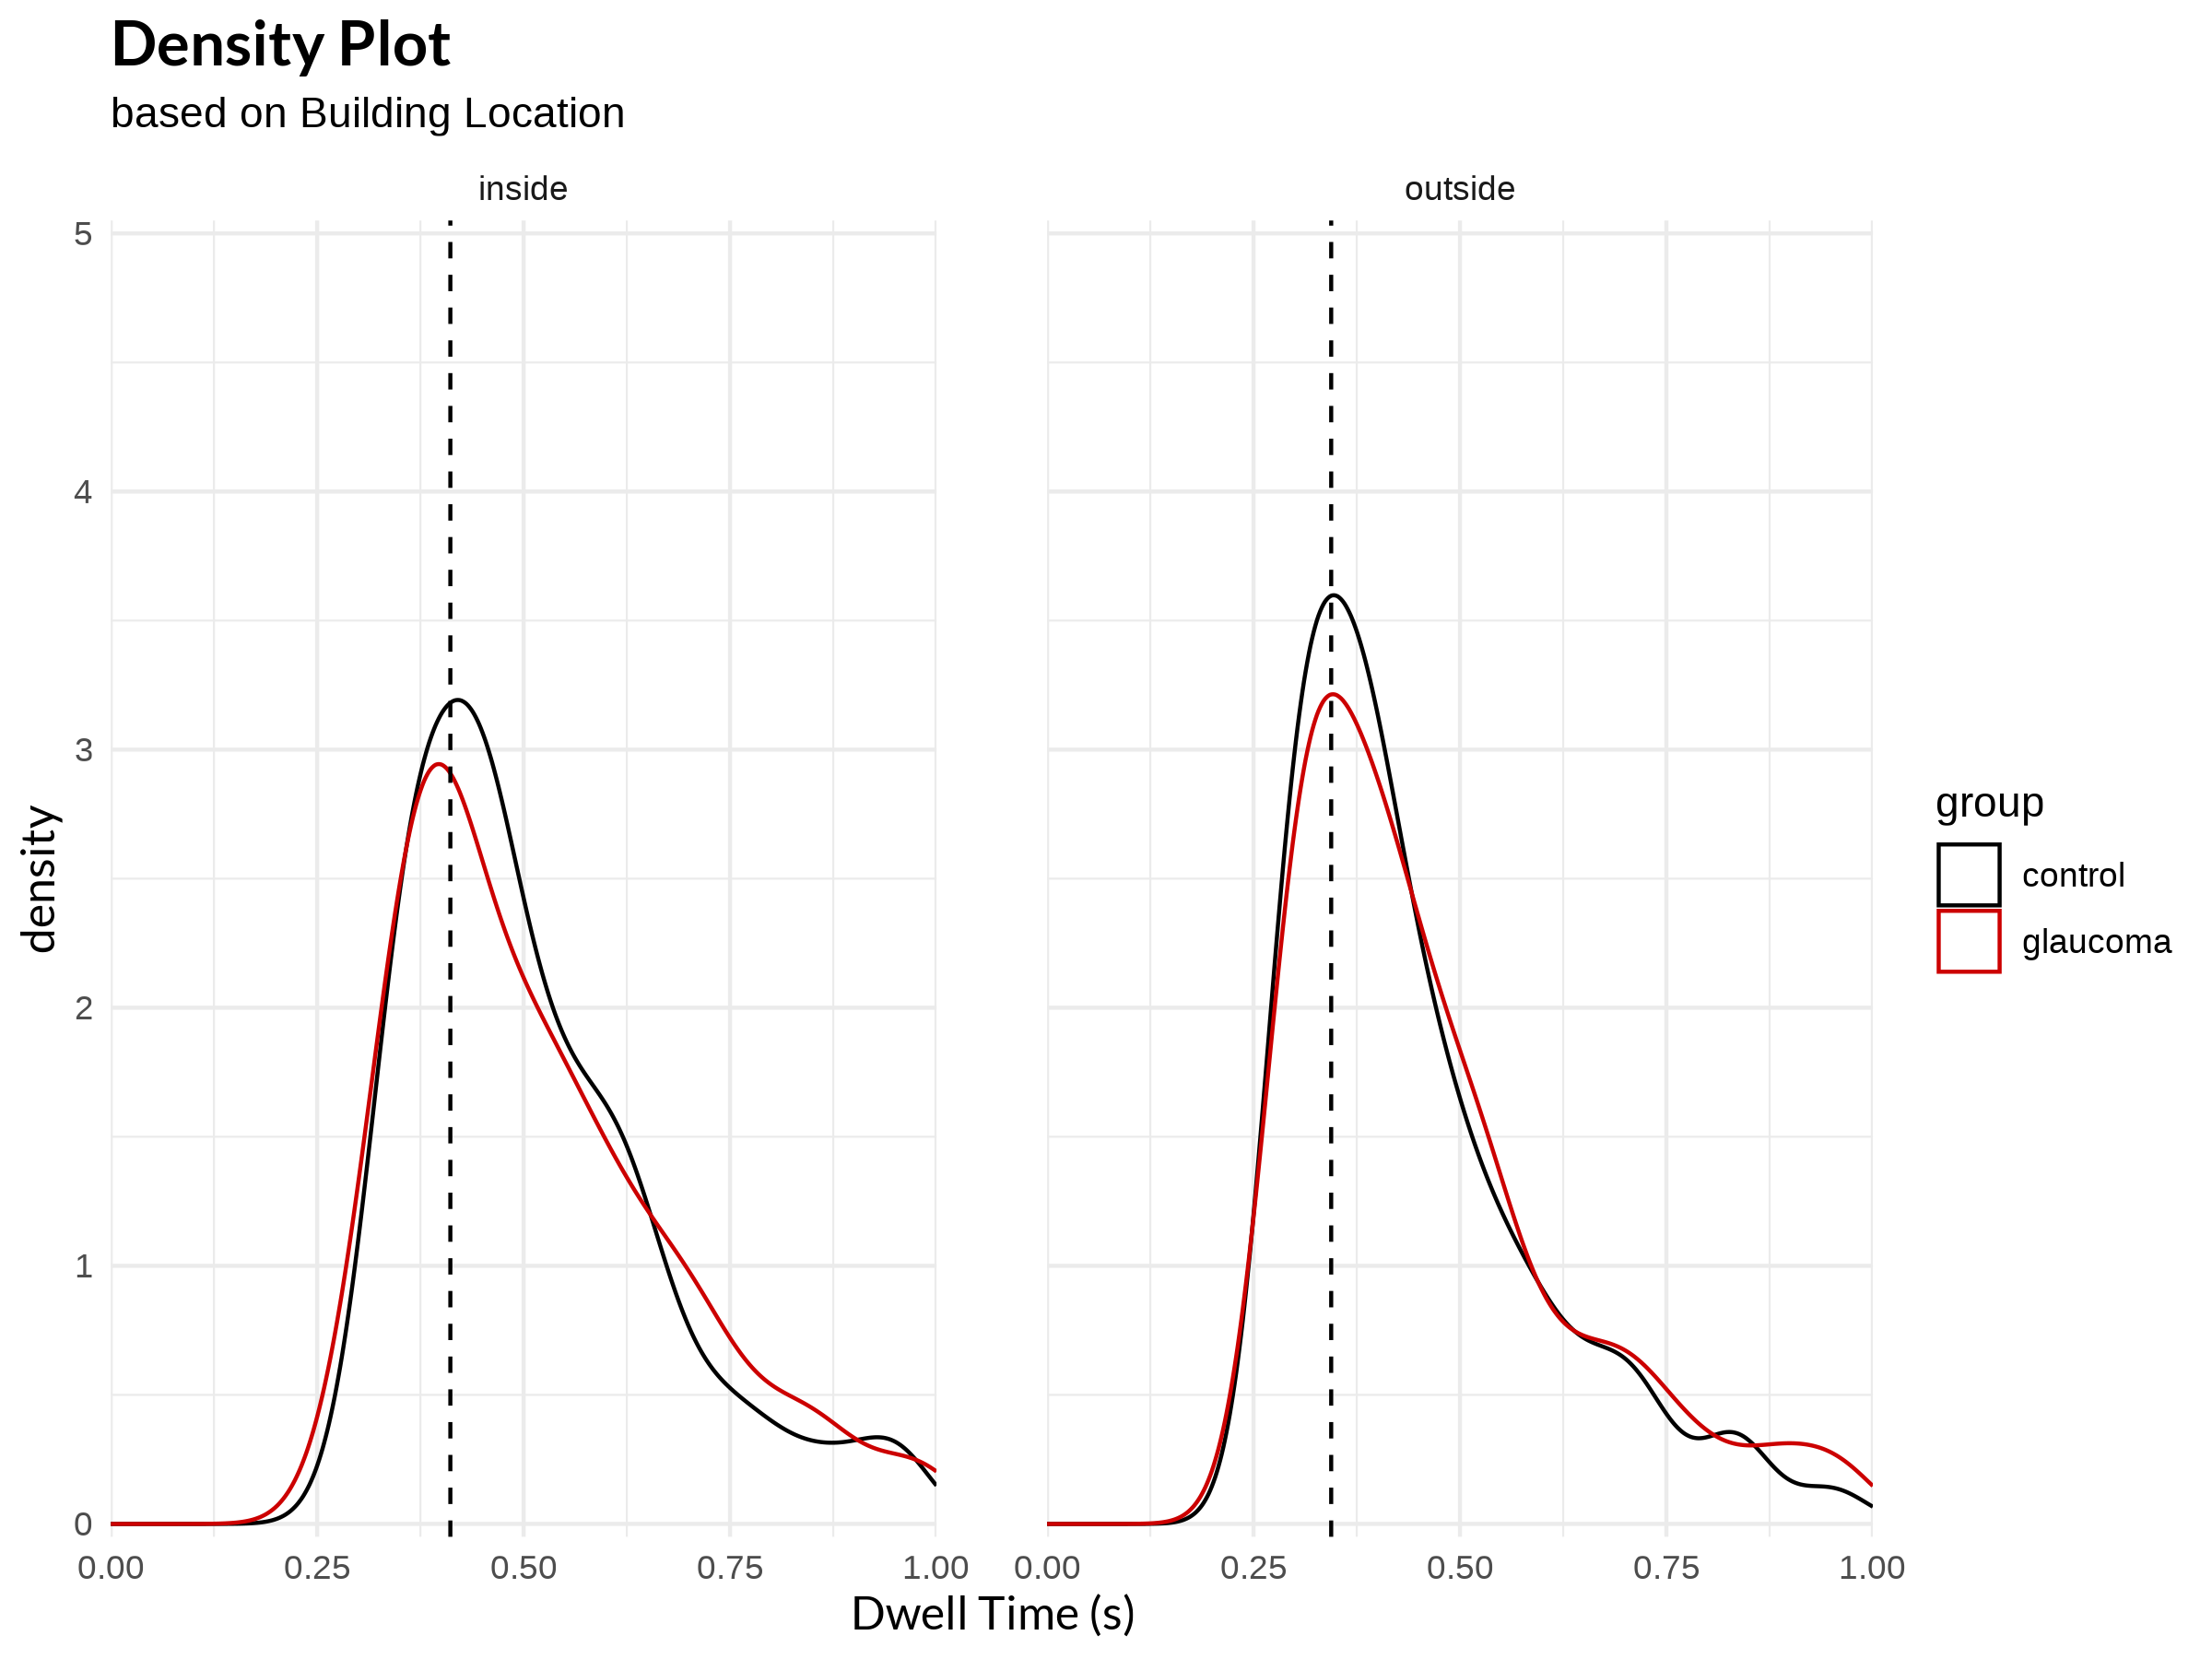

In [ ]:
mode_value_inside <- df %>%
  filter(group == "control" & building_location == "inside") %>%
  pull(median_clusterDuration) %>%
  density() %>%
  {.$x[which.max(.$y)]}
mode_value_outside <- df %>%
  filter(group == "control" & building_location == "outside") %>%
  pull(median_clusterDuration) %>%
  density() %>%
  {.$x[which.max(.$y)]}
mode_value_inside
mode_value_outside

mode_values <- tibble(building_location = c("inside", "outside"), x = c(mode_value_inside - 0.01, mode_value_outside - 0.005))

fig <- df |>
  ggplot(aes(x = median_clusterDuration, color = group)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  scale_x_continuous(limits = c(0, 1), expand = c(0,0)) +
  scale_y_continuous(limits = c(0, 5), expand = c(0.01, 0)) +
  geom_vline(aes(xintercept = x), linetype = "dashed", data = mode_values) +
  facet_wrap(~ building_location) +  # Facet by the interaction of the two factors
  theme_minimal() +
  labs(title = "Density Plot",
      subtitle = "based on Building Location",
       x = "Dwell Time (s)",
       y = "density") +
  theme(
    plot.title = element_text(family = "lato", size = 16, face = "bold"),
    axis.title.x = element_text(family = "lato", size = 12),
    axis.title.y = element_text(family = "lato", size = 12),
    panel.spacing = unit(2, "lines")
   ) +
   scale_color_manual(values = c("black", "#CC0000"))
fig
#ggsave("naisu_only_location.svg", fig)

In [18]:
library(lme4)
library(emmeans)
library(performance)
library(MASS)

In [23]:
library(scales)
df_filtered <- df %>%
    filter(median_clusterDuration < 4)

vf_df_combine <- vf_df %>%
    mutate(
        group = tolower(group),
        groupT = factor(group, c("glaucoma", "control")),
        PID = factor(vr_id),
        mean_pRFNL = rescale((pRFNL_right + pRFNL_left) / 2, to = c(-1, 1)),
        no_scaled_pRFNL = (pRFNL_right + pRFNL_left) / 2,
        gender = factor(gender)
    ) %>% 
    group_by(PID) %>%
    mutate(
        worst_MD = min(MD_right, MD_left, na.rm = TRUE),
        best_MD = max(MD_right, MD_left,na.rm = TRUE)
    ) %>% ungroup() %>%
    mutate(
        unscaled_worst_MD = worst_MD,
        unscaled_best_MD = best_MD,
        worst_MD = rescale(worst_MD, to = c(-1, 1)),
        best_MD = rescale(best_MD, to = c(-1, 1))
    )


vf_df_pick <- vf_df_combine %>% dplyr::select(
    PID, worst_MD, unscaled_worst_MD, 
    unscaled_best_MD, best_MD, 
    mean_pRFNL, no_scaled_pRFNL, 
    groupT, gender
)
df_combined <- df_filtered %>% left_join(vf_df_pick)
#vf_df_pick %>% dplyr::select(PID, mean_pRFNL) %>% unique()
#df_combined %>% dplyr::select(PID, groupT, worst_MD) %>% unique()


Joining with `by = join_by(PID)`


In [28]:
# Fit a generalized linear mixed model (GLMM) using glmer
## adjust with pRFNL and found an effect of group
model_0 <- glmer(median_clusterDuration ~  (1 | PID) + (1 | hitObjectColliderName), data = df_combined, family = Gamma(link = "inverse"))
model_inter <- glmer(median_clusterDuration ~  building_location +  (1 | PID) + (1 | hitObjectColliderName), data = df_combined, family = Gamma(link = "inverse"))
model_full <- glmer(median_clusterDuration ~   building_location + groupT + (1 | PID) +  (1 | hitObjectColliderName), data = df_combined, family = Gamma(link = "inverse"))
model_interact <- glmer(median_clusterDuration ~  building_location * groupT + (1 | PID) + (1 | hitObjectColliderName), data = df_combined, family = Gamma(link = "inverse"))
# model0 <- glmer(median_clusterDuration ~ 1 + (1 | PID) + (1| hitObjectColliderName), data = df, Gamma(link = "inverse"))


In [25]:
#anova(model_00, model_0_PID)
anova(model_full, model_inter)
r2_nakagawa(model_full)
r2_nakagawa(model_inter)
model_full %>% tidy()


,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_inter,5,-1007.70,-981.6643,508.8499,-1017.70,NA,NA,NA
model_full,6,-1006.38,-975.1376,509.1901,-1018.38,0.6804367,1,0.4094364


# R2 for Mixed Models

  Conditional R2: 0.578
     Marginal R2: 0.176

# R2 for Mixed Models

  Conditional R2: 0.576
     Marginal R2: 0.167

effect,group,term,estimate,std.error,statistic,p.value
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,NA,(Intercept),2.5160703,0.1154968,21.7847564,3.236622e-105
fixed,NA,building_locationinside,-0.4614143,0.1172673,-3.9347236,8.329249e-05
fixed,NA,groupglaucoma,-0.1023035,0.1218853,-0.8393425,4.012772e-01
ran_pars,hitObjectColliderName,sd__(Intercept),0.3261774,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.1480046,NA,NA,NA
ran_pars,Residual,sd__Observation,0.3667264,NA,NA,NA


#### Exploratory Analysis

1. Know that there is no difference between glaucoma and control when considering the variance of those.

In [12]:
building_intercepts <- ranef(model_full)$hitObjectColliderName
threshold <- quantile(building_intercepts[,1], 0.75) # top 25% of buildings
high_building_names <- building_intercepts %>% rownames() %>% .[building_intercepts[,1] > threshold]
df_exploration <- df_combined %>%
    mutate(
        high_intercept_building = ifelse(hitObjectColliderName %in% high_building_names, 1, 0),
        high_intercept_building = factor(high_intercept_building, levels = c(0, 1), labels = c("low", "high")),
    )
df_exploration %>% pull(high_intercept_building) %>% unique()


conditional_model <- glmer(median_clusterDuration ~  groupT * high_intercept_building * building_location + (1 | PID), data = df_exploration, family = Gamma(link = "inverse"))
anova(conditional_model)
# Create a reference grid
ref_grid <- ref_grid(conditional_model)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ groupT)
emmeans(new_grid, ~ groupT * high_intercept_building) %>% pairs()

[1] high low 
Levels: low high

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
groupT,1,0.1484340,0.1484340,0.8935138
high_intercept_building,1,28.2026779,28.2026779,169.7688881
building_location,1,12.6468594,12.6468594,76.1290568
groupT:high_intercept_building,1,0.1547874,0.1547874,0.9317585
groupT:building_location,1,0.2077314,0.2077314,1.2504604
high_intercept_building:building_location,1,0.2419507,0.2419507,1.4564469
groupT:high_intercept_building:building_location,1,0.1321700,0.1321700,0.7956106


NOTE: Results may be misleading due to involvement in interactions

NOTE: Results may be misleading due to involvement in interactions



 contrast                     estimate     SE  df z.ratio p.value
 glaucoma low - control low    0.02658 0.0460 Inf   0.578  0.9388
 glaucoma low - glaucoma high  0.19180 0.0228 Inf   8.426  <.0001
 glaucoma low - control high   0.18993 0.0386 Inf   4.921  <.0001
 control low - glaucoma high   0.16522 0.0357 Inf   4.628  <.0001
 control low - control high    0.16335 0.0200 Inf   8.164  <.0001
 glaucoma high - control high -0.00186 0.0254 Inf  -0.073  0.9999

Results are averaged over the levels of: building_location 
P value adjustment: tukey method for comparing a family of 4 estimates 

#### Model Comparisons

In [26]:
anova(model_full)
anova(model_interact, model_full)
anova(model_full, model_inter)
anova(model_inter, model_0)

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
building_location,1,4.5917719,4.5917719,34.142559
group,1,0.2239769,0.2239769,1.665401


,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_full,6,-1006.380,-975.1376,509.1901,-1018.380,NA,NA,NA
model_interact,7,-1004.837,-968.3874,509.4186,-1018.837,0.4569406,1,0.4990573


,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_inter,5,-1007.70,-981.6643,508.8499,-1017.70,NA,NA,NA
model_full,6,-1006.38,-975.1376,509.1901,-1018.38,0.6804367,1,0.4094364


,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_0,4,-994.9851,-974.1566,501.4925,-1002.985,NA,NA,NA
model_inter,5,-1007.6998,-981.6643,508.8499,-1017.700,14.71476,1,0.0001250634


There is a better way for the estimation below. 

In order to take average, one should do everything in model scale then apply inverse link function to get the values back into response scale.

In [29]:
# Get marginal means for f1 (averaged over f2), excluding random effects
emm_fixed <- emmeans(model_full, ~ groupT)
inv_link_fun <- family(model_full)$linkinv
 #at = list(hitObjectColliderName = NA), re.form = ~ (1 | PID))

estimation_pid <- vf_df_pick
# Convert to data frame
fixed_preds <- emm_fixed %>% as_tibble() %>% dplyr::select(groupT, emmean)
# Now add the random effects for each PID level manually
r1_effects <- ranef(model_full)$PID %>%
    rownames_to_column() %>%
    rename(
        PID = rowname,
        ran_eff = `(Intercept)`
    ) 
pid_estimations <- vf_df_pick %>% dplyr::select(PID, groupT) %>%
    left_join(r1_effects) %>%
    left_join(fixed_preds) %>%
    mutate(
        EMM = ran_eff + emmean,
        EMM_response = inv_link_fun(EMM)
    )
pid_estimations

Joining with `by = join_by(PID)`
Joining with `by = join_by(groupT)`


PID,groupT,ran_eff,emmean,EMM,EMM_response
<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
2002,control,-0.008951182,2.261600,2.252649,0.4439219
2005,control,-0.211151133,2.261600,2.050449,0.4876982
2008,control,-0.075062156,2.261600,2.186538,0.4573441
2009,control,0.035199502,2.261600,2.296799,0.4353885
2015,control,-0.305244993,2.261600,1.956355,0.5111548
2016,control,-0.188197363,2.261600,2.073402,0.4822991
2017,control,-0.048595690,2.261600,2.213004,0.4518745
2018,control,-0.078889734,2.261600,2.182710,0.4581461
2024,control,0.112804339,2.261600,2.374404,0.4211583


In [55]:
model_full %>% tidy()

# Create a reference grid
ref_grid <- ref_grid(model_full)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ groupT)
emm_building <- emmeans(new_grid, ~ building_location)
emm_eff <- emmeans(model_full, ~ groupT)
emm_building_eff <- emmeans(model_full, ~ building_location)


summary(emm)
summary(emm_building)
pairs(emm, adjust = "tukey")
r2_nakagawa(model_full)
r2_nakagawa(model_inter)
r2_nakagawa(model_0)
r2_nakagawa(model_interact)

effect,group,term,estimate,std.error,statistic,p.value
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,NA,(Intercept),2.44280578,0.1185168,20.611474,2.165371e-94
fixed,NA,groupTcontrol,0.04936107,0.1244964,0.396486,6.917465e-01
fixed,NA,building_locationinside,-0.46113434,0.1172341,-3.933449,8.373578e-05
ran_pars,hitObjectColliderName,sd__(Intercept),0.32640208,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.15052955,NA,NA,NA
ran_pars,Residual,sd__Observation,0.36701271,NA,NA,NA


,groupT,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,glaucoma,0.4569949,0.02499367,Inf,0.4080082,0.5059816
2,control,0.4468088,0.02354968,Inf,0.4006523,0.4929654


,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,0.4053113,0.01645965,Inf,0.3730510,0.4375716
2,inside,0.4984925,0.03081215,Inf,0.4381018,0.5588832


 contrast           estimate     SE  df z.ratio p.value
 glaucoma - control   0.0102 0.0257 Inf   0.396  0.6922

Results are averaged over the levels of: building_location 

# R2 for Mixed Models

  Conditional R2: 0.577
     Marginal R2: 0.170

# R2 for Mixed Models

  Conditional R2: 0.576
     Marginal R2: 0.167

# R2 for Mixed Models

  Conditional R2: 0.521
     Marginal R2: 0.000

# R2 for Mixed Models

  Conditional R2: 0.577
     Marginal R2: 0.173

`summarise()` has grouped output by 'PID', 'mean_pRFNL'. You can override using
the `.groups` argument.


[1]  0.8857143  0.5238095         NA -0.8857143  0.5238095  0.1047619
 [7]  0.4285714  0.3142857  0.8476190         NA  0.4857143  1.0000000
[13] -0.3523810 -0.6761905  0.8285714 -0.3333333 -1.0000000 -0.5809524

$PID


$hitObjectColliderName


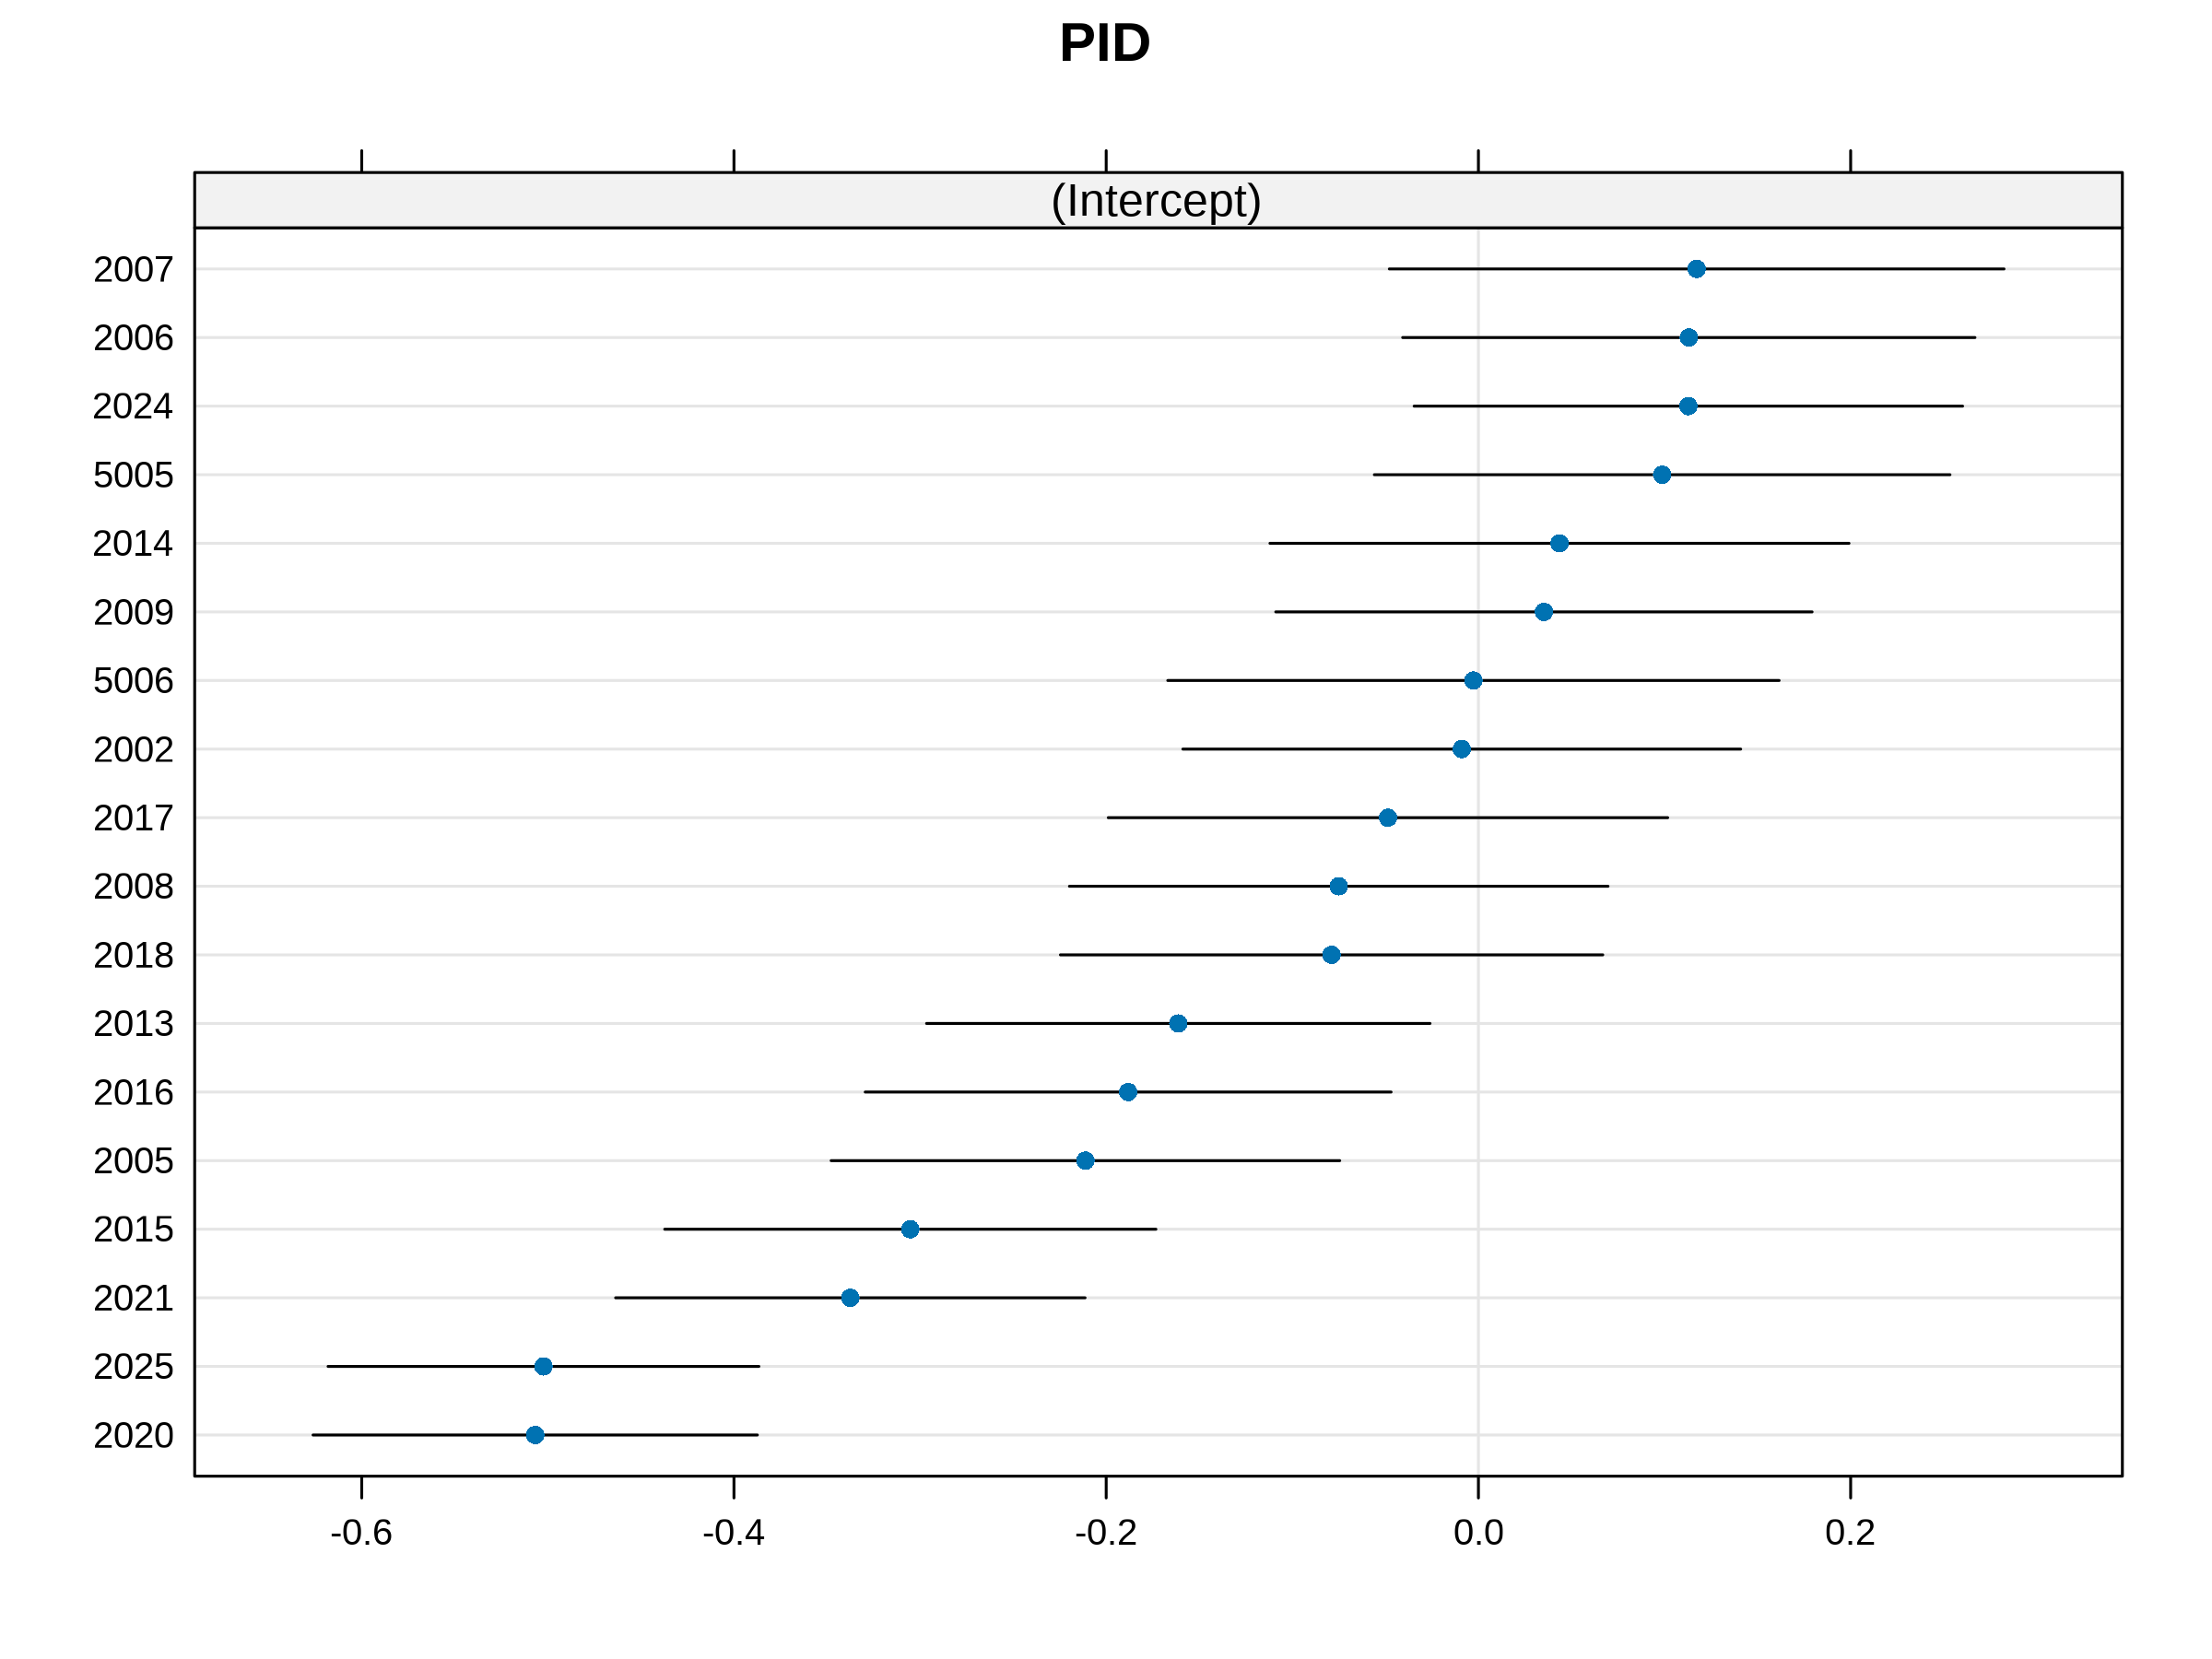

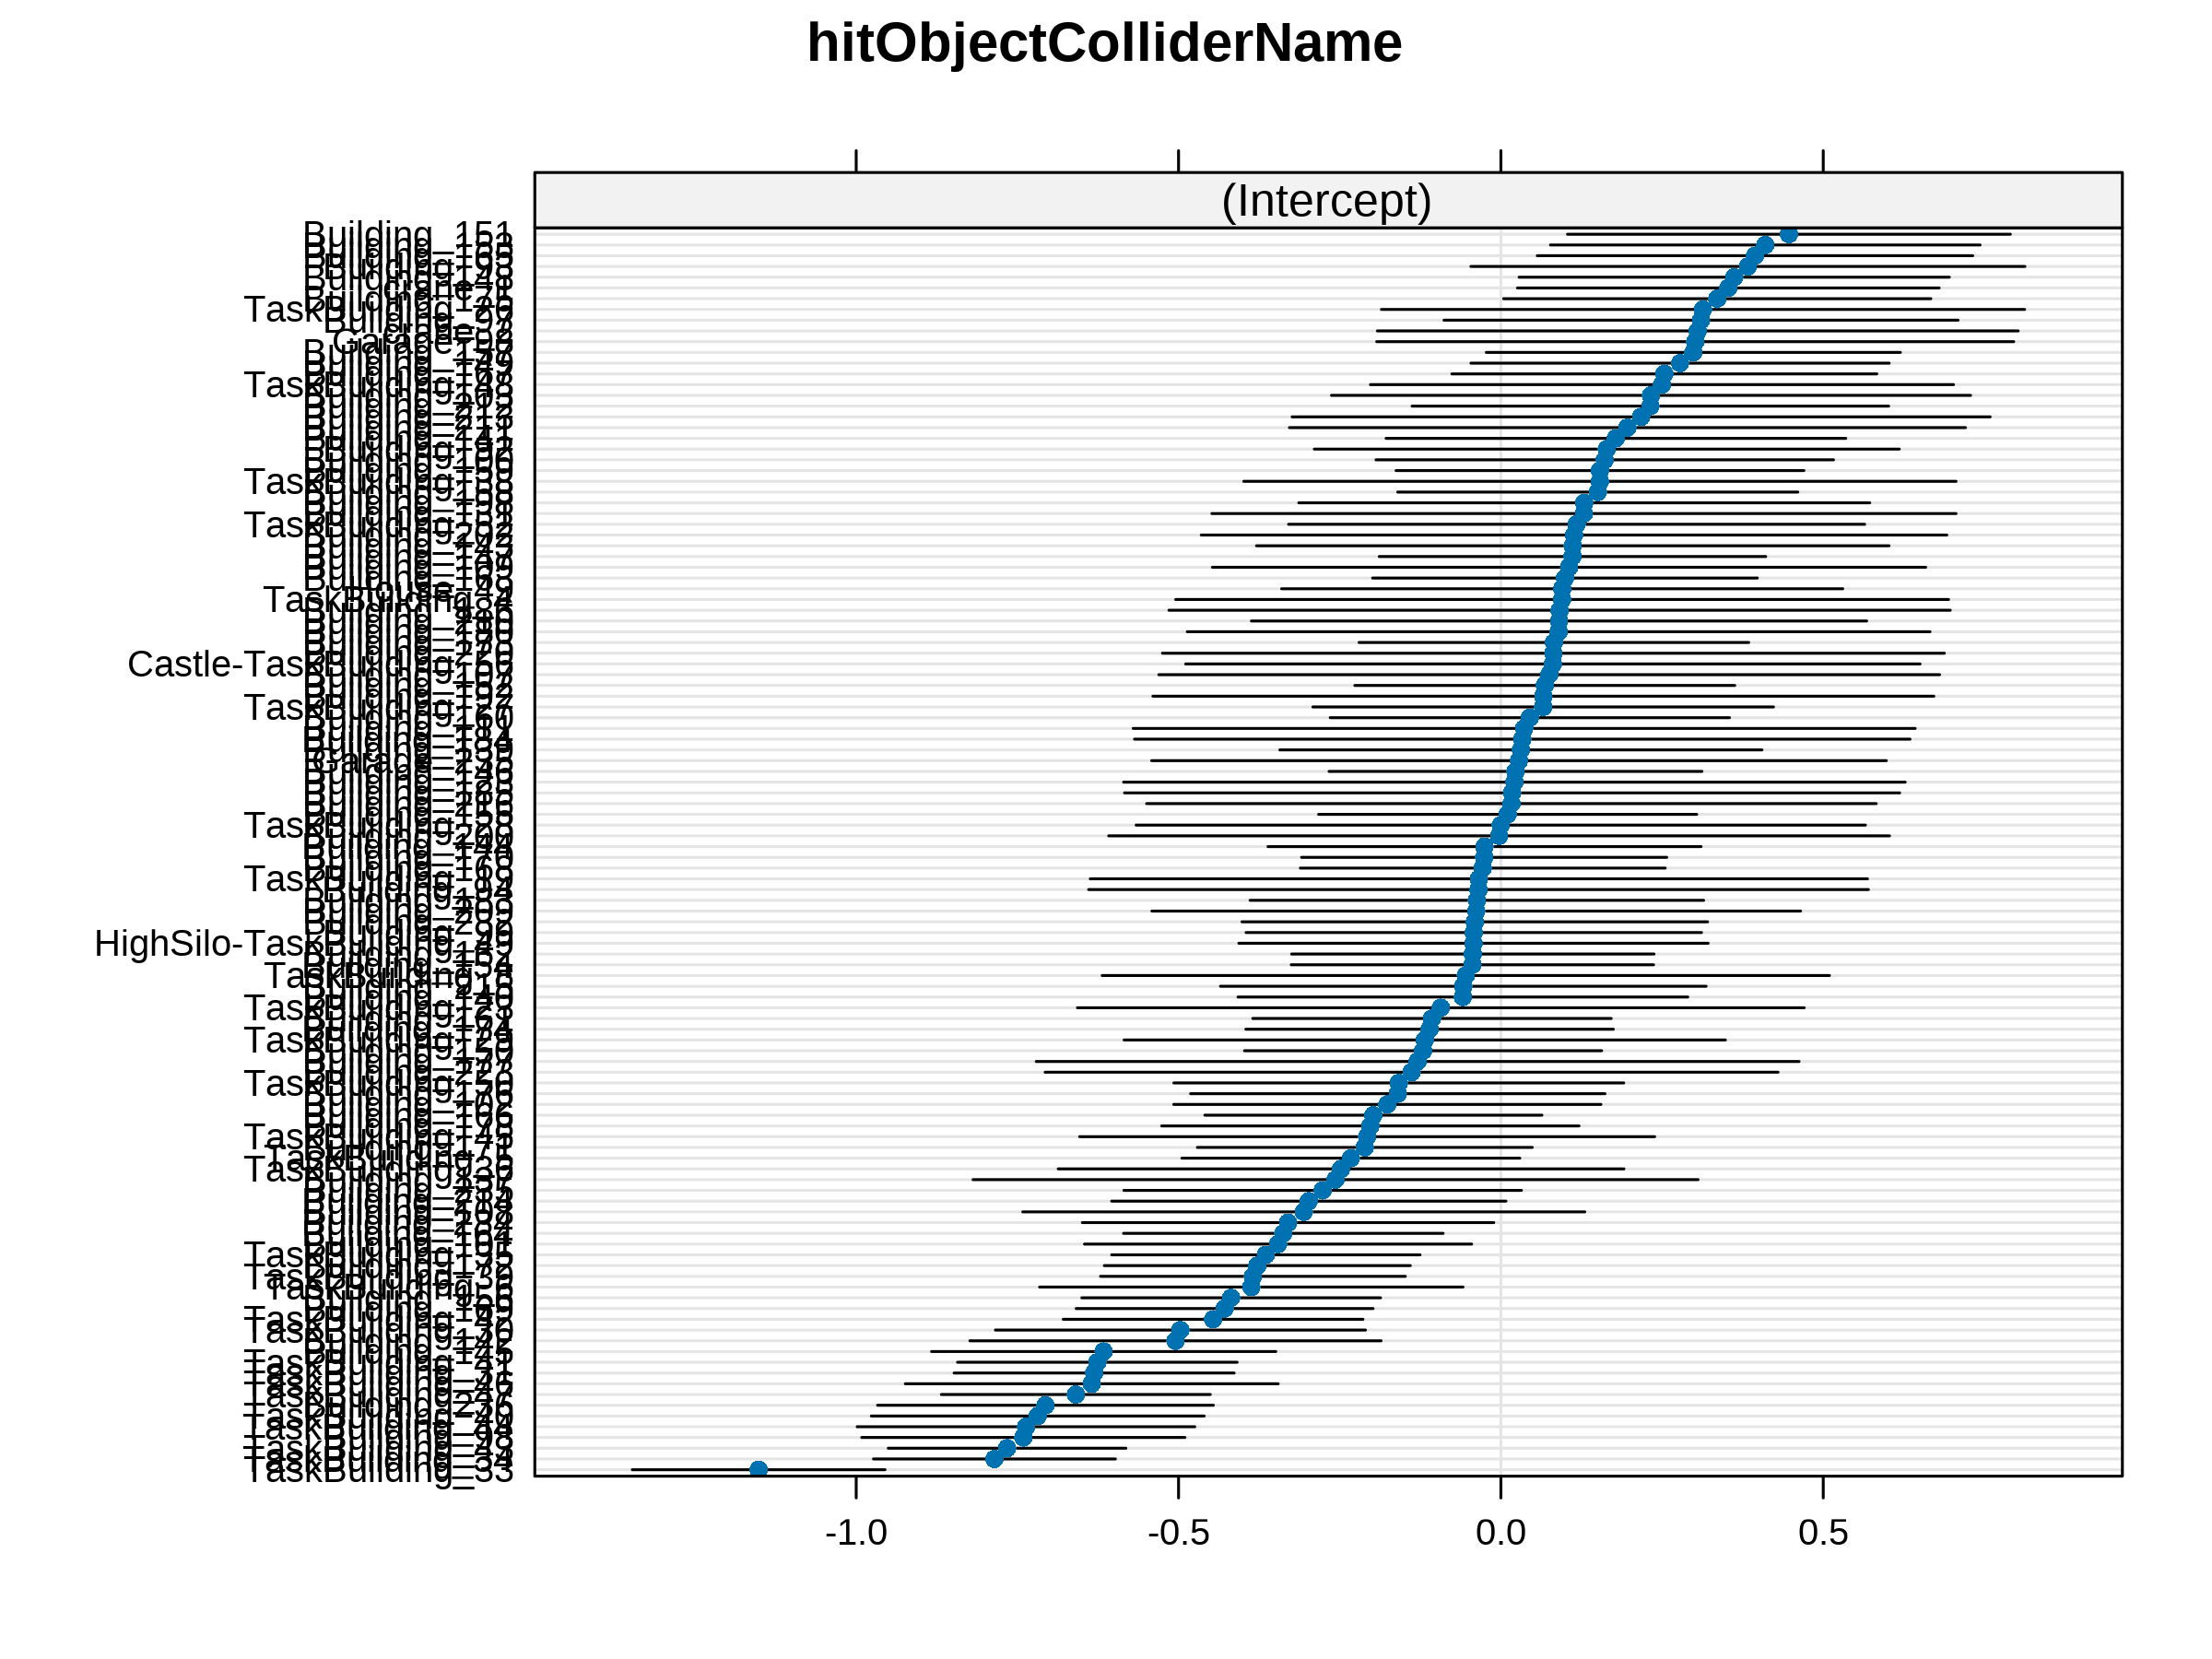

In [ ]:
df_combined_predict <- df_combined %>%
    mutate(
        predicted = predict(model_full, type = "response"),
        residuals = residuals(model_full)
    )
lattice::dotplot(ranef(model_full, which = "PID", condVar = TRUE))
lattice::dotplot(ranef(model_full, which = "hitObjectColliderName", condVar = TRUE))


Attaching package: ‘patchwork’


The following object is masked from ‘package:MASS’:

    area


Warning message:
“For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning.”


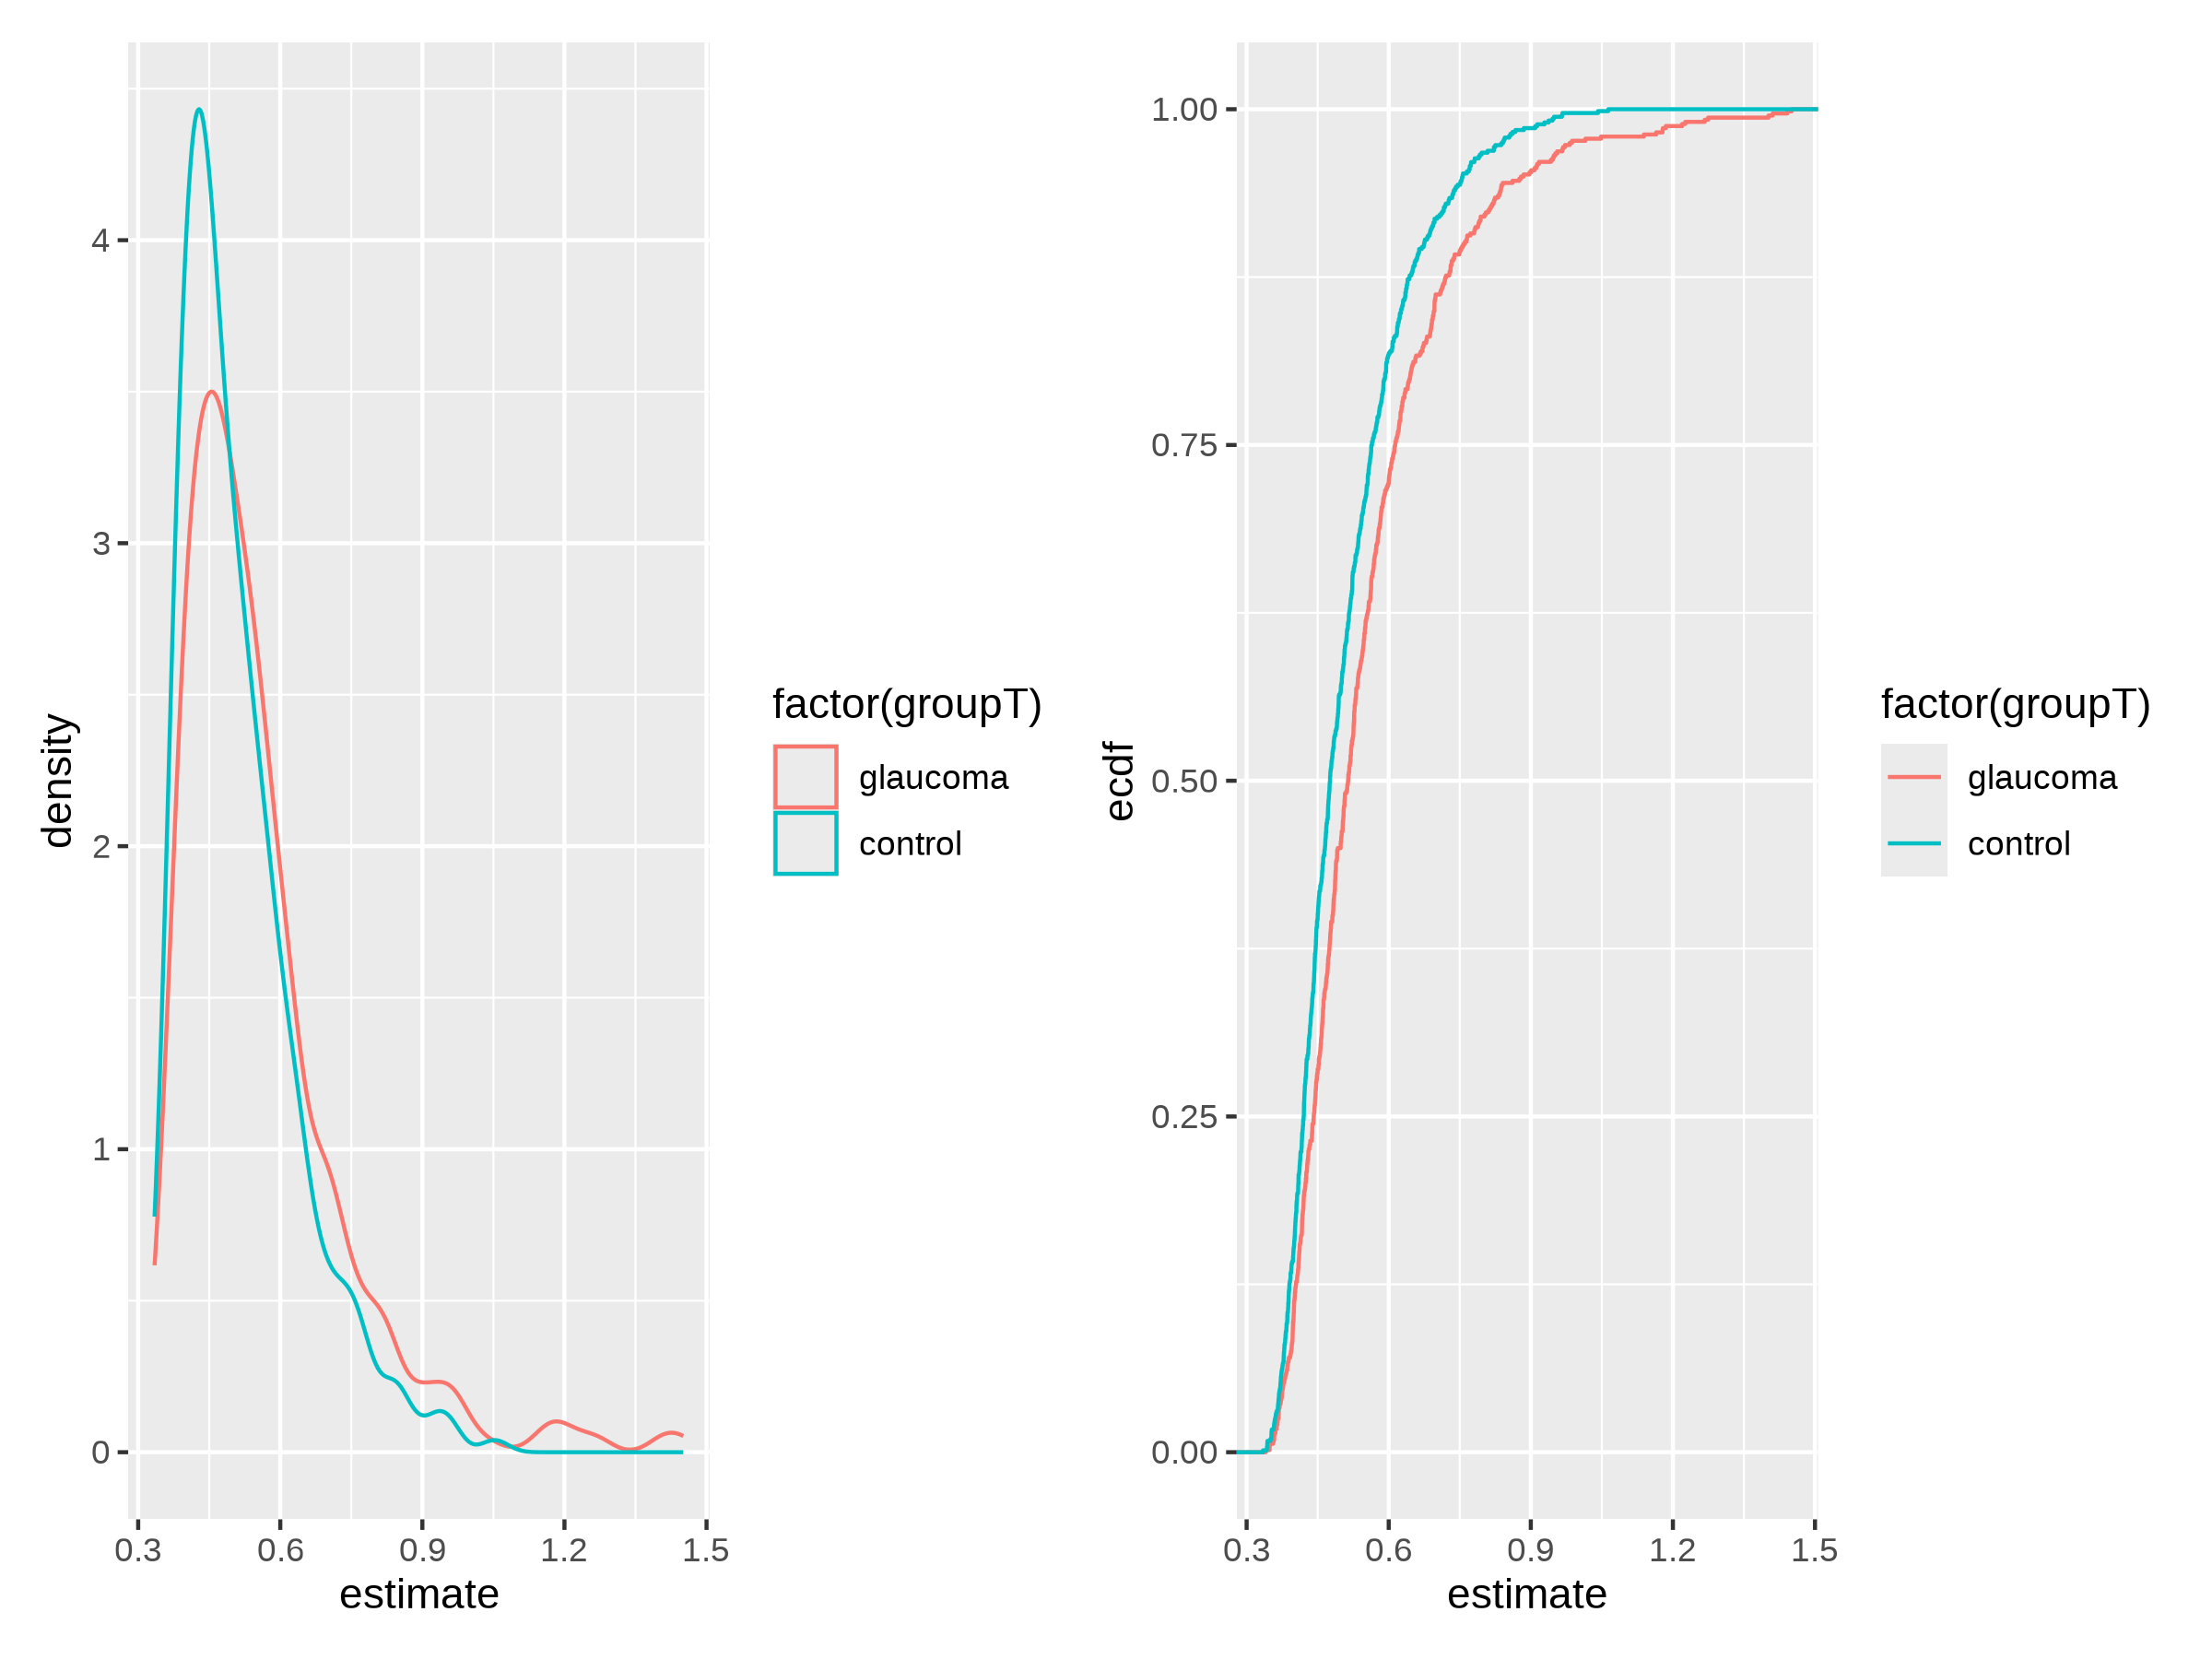

In [58]:
library(patchwork)

p <- predictions(model_full)

# Histogram
p1 = ggplot(p) +
  geom_density(aes(estimate, color = factor(groupT))) +
  scale_fill_grey()

# Empirical Cumulative Distribution Function
p2 = ggplot(p) +
  stat_ecdf(aes(estimate, colour = factor(groupT)))

p1 + p2

In [59]:
model_0 %>% tidy() %>% gt() %>% capture.output() %>% IRdisplay::display_html()
model_inter %>% tidy() %>% gt() %>% capture.output() %>% IRdisplay::display_html()
model_full %>% tidy() %>% gt() %>% capture.output() %>% IRdisplay::display_html()


effect,group,term,estimate,std.error,statistic,p.value
fixed,NA,(Intercept),2.3424059,0.0973951,24.05055,8.237537e-128
ran_pars,hitObjectColliderName,sd__(Intercept),0.3572693,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.1503112,NA,NA,NA
ran_pars,Residual,sd__Observation,0.3717292,NA,NA,NA


effect,group,term,estimate,std.error,statistic,p.value
fixed,NA,(Intercept),2.4683607,0.1004680,24.568617,2.735844e-133
fixed,NA,building_locationinside,-0.4611125,0.1172429,-3.932967,8.390379e-05
ran_pars,hitObjectColliderName,sd__(Intercept),0.3265466,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.1515073,NA,NA,NA
ran_pars,Residual,sd__Observation,0.3671146,NA,NA,NA


effect,group,term,estimate,std.error,statistic,p.value
fixed,NA,(Intercept),2.44280578,0.1185168,20.611474,2.165371e-94
fixed,NA,groupTcontrol,0.04936107,0.1244964,0.396486,6.917465e-01
fixed,NA,building_locationinside,-0.46113434,0.1172341,-3.933449,8.373578e-05
ran_pars,hitObjectColliderName,sd__(Intercept),0.32640208,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.15052955,NA,NA,NA
ran_pars,Residual,sd__Observation,0.36701271,NA,NA,NA


In [60]:
df_combined_full <- df_combined %>% filter(!is.na(mean_pRFNL))
# Test the pRNFL explanation
model_0_gl <- glmer(median_clusterDuration ~ 1 + (1 | PID) + (1 | hitObjectColliderName), data = df_combined_full, family = Gamma(link = "inverse"))
model_0_gl_bl <- glmer(median_clusterDuration ~  building_location + (1 | PID) + (1 | hitObjectColliderName), data = df_combined_full, family = Gamma(link = "inverse"))
model_0_gl_gr_bl <- glmer(median_clusterDuration ~  building_location + groupT +  (1 | PID) + (1 | hitObjectColliderName), data = df_combined_full, family = Gamma(link = "inverse"))
model_0_gl_bl_pRFNL <- glmer(median_clusterDuration ~ building_location + groupT + mean_pRFNL + (1 | PID) + (1 | hitObjectColliderName), data = df_combined_full, family = Gamma(link = "inverse"))


anova(model_0_gl_bl, model_0_gl)
#anova(model_0_gl_bl_pRFNL, model_0_gl_bl)
anova(model_0_gl_gr_bl, model_0_gl_bl)
anova(model_0_gl_bl_pRFNL, model_0_gl_bl)

model_0_gl_gr_bl %>% tidy() %>% gt() %>% capture.output() %>% IRdisplay::display_html()
model_0_gl_bl_pRFNL %>% tidy() %>% gt() %>% capture.output() %>% IRdisplay::display_html()
r2_nakagawa(model_0_gl)
r2_nakagawa(model_0_gl_bl)
#r2_nakagawa(model_0_gl_gr_bl)
r2_nakagawa(model_0_gl_bl_pRFNL)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_0_gl,4,-871.8758,-851.5088,439.9379,-879.8758,NA,NA,NA
model_0_gl_bl,5,-883.7898,-858.3311,446.8949,-893.7898,13.914,1,0.0001913678


,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_0_gl_bl,5,-883.7898,-858.3311,446.8949,-893.7898,NA,NA,NA
model_0_gl_gr_bl,6,-882.3198,-851.7693,447.1599,-894.3198,0.5300012,1,0.4666064


,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_0_gl_bl,5,-883.7898,-858.3311,446.8949,-893.7898,NA,NA,NA
model_0_gl_bl_pRFNL,7,-880.7216,-845.0794,447.3608,-894.7216,0.9317764,2,0.6275774


effect,group,term,estimate,std.error,statistic,p.value
fixed,NA,(Intercept),2.41324007,0.1243479,19.4071698,6.712393e-84
fixed,NA,building_locationinside,-0.45485810,0.1193476,-3.8112045,1.382913e-04
fixed,NA,groupTcontrol,0.09718845,0.1313159,0.7401118,4.592321e-01
ran_pars,hitObjectColliderName,sd__(Intercept),0.33408203,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.14968188,NA,NA,NA
ran_pars,Residual,sd__Observation,0.36568857,NA,NA,NA


effect,group,term,estimate,std.error,statistic,p.value
fixed,NA,(Intercept),2.3702240,0.1392438,17.0221167,5.629808e-65
fixed,NA,building_locationinside,-0.4548428,0.1193439,-3.8111932,1.382976e-04
fixed,NA,groupTcontrol,0.2059977,0.2134177,0.9652325,3.344284e-01
fixed,NA,mean_pRFNL,-0.1035030,0.1620466,-0.6387239,5.230026e-01
ran_pars,hitObjectColliderName,sd__(Intercept),0.3341219,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.1479006,NA,NA,NA
ran_pars,Residual,sd__Observation,0.3657792,NA,NA,NA


# R2 for Mixed Models

  Conditional R2: 0.531
     Marginal R2: 0.000

# R2 for Mixed Models

  Conditional R2: 0.583
     Marginal R2: 0.161

# R2 for Mixed Models

  Conditional R2: 0.588
     Marginal R2: 0.176

#### Node difference

In [44]:
df_node <- read_csv("glaucoma_io_building_node.csv")

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID)
    ) |>
    rename(
        building_location = inside,
        group = category,
        duration = clusterDuration
    ) |>
    group_by(PID, group, hitObjectColliderName, building_location) |>
    summarize(
        mean_connections = mean(connections)
    ) |>
    ungroup() |>
    filter(mean_connections > 0)

df_node <- df_node %>% mutate(
    group = factor(ifelse(PID %in% c(2006,2007,2013,2014,2021,2020,2025,5005,5006), "glaucoma", "control"))
)

Rows: 12015 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has grouped output by 'PID', 'group', 'hitObjectColliderName'.
You can override using the `.groups` argument.


In [31]:
overdisp_fun <- function(model) {
    rdf <- df.residual(model)
    rp <- residuals(model,type="pearson")
    Pearson.chisq <- sum(rp^2)
    prat <- Pearson.chisq/rdf
    pval <- pchisq(Pearson.chisq, df=rdf, lower.tail=FALSE)
    c(chisq=Pearson.chisq,ratio=prat,rdf=rdf,p=pval)
}

tidy_quasi <- function(model, phi=overdisp_fun(model)["ratio"],
                       conf.level=0.95) {
    tt <- (tidy(model, effects="fixed")
       %>% mutate(std.error=std.error*sqrt(phi),
                   statistic=estimate/std.error,
                   p.value=2*pnorm(abs(statistic), lower.tail=FALSE))
    )
    return(tt)
}

In [32]:
node_model_0 <- glmer(mean_connections ~ 1 + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())
node_model_inter <- glmer(mean_connections ~ building_location + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())
node_model_full <- glmer(mean_connections ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())
node_model_interact <- glmer(mean_connections ~ building_location * group + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())

In [119]:
node_model_0 %>% tidy_quasi() %>% gt() %>% capture.output() %>% IRdisplay::display_html()
node_model_0 %>% tidy() %>% gt() %>% capture.output() %>% IRdisplay::display_html()
node_model_inter %>% tidy_quasi() %>% gt() %>% capture.output() %>% IRdisplay::display_html()
node_model_full %>% tidy_quasi() %>% gt() %>% capture.output() %>% IRdisplay::display_html()

effect,term,estimate,std.error,statistic,p.value
fixed,(Intercept),1.32555,0.07176605,18.47044,3.571826e-76


effect,group,term,estimate,std.error,statistic,p.value
fixed,NA,(Intercept),1.3255503,0.0833889,15.896,6.753852e-57
ran_pars,hitObjectColliderName,sd__(Intercept),0.6033461,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.2377477,NA,NA,NA


effect,term,estimate,std.error,statistic,p.value
fixed,(Intercept),1.0425350,0.07409254,14.07072,5.748499e-45
fixed,building_locationinside,0.7966479,0.08604215,9.25881,2.067236e-20


effect,term,estimate,std.error,statistic,p.value
fixed,(Intercept),1.1775001,0.07948026,14.815000,1.171889e-49
fixed,building_locationinside,0.7966618,0.08605806,9.257260,2.097448e-20
fixed,groupglaucoma,-0.2697065,0.08140587,-3.313109,9.226515e-04


#### Exploration for Node Degree in Glaucoma

In [35]:
anova(node_model_0, node_model_inter)
anova(node_model_inter, node_model_full)
anova(node_model_full, node_model_interact)
r2_nakagawa(node_model_0)
r2_nakagawa(node_model_inter)
r2_nakagawa(node_model_full)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
node_model_0,3,6110.289,6125.919,-3052.144,6104.289,NA,NA,NA
node_model_inter,4,6057.596,6078.437,-3024.798,6049.596,54.69204,1,1.409763e-13


,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
node_model_inter,4,6057.596,6078.437,-3024.798,6049.596,NA,NA,NA
node_model_full,5,6052.866,6078.917,-3021.433,6042.866,6.729995,1,0.009480486


,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
node_model_full,5,6052.866,6078.917,-3021.433,6042.866,NA,NA,NA
node_model_interact,6,6054.063,6085.323,-3021.031,6042.063,0.8037193,1,0.3699837


# R2 for Mixed Models

  Conditional R2: 0.683
     Marginal R2: 0.000

# R2 for Mixed Models

  Conditional R2: 0.691
     Marginal R2: 0.252

# R2 for Mixed Models

  Conditional R2: 0.689
     Marginal R2: 0.276

In [45]:
df_node_combined <- df_node %>% left_join(vf_df_pick)

Joining with `by = join_by(PID)`


Mediation analysis would not work as there is no valid method to control that with two cross-factor random effects. It's defined in models with one random effect. To check the effect of it, one would follow the similar reasoning. Check the effect of pRFNL, worst_MD, best_MD in the model.

Change below code to get pRFNL, MD worst, and best graphs

In [290]:

df_node_combined_filtered <- df_node_combined %>% filter(!is.na(worst_MD))
    #mutate(mean_connections = ifelse(group == "control", mean_connections + 10, mean_connections))

model_0_filtered <- glmer(mean_connections ~ 1 + (1 | PID) + (1 | hitObjectColliderName), data = df_node_combined_filtered, family = poisson())
model_bl_filtered <- glmer(mean_connections ~ building_location + (1 | PID) + (1 | hitObjectColliderName), data = df_node_combined_filtered, family = poisson())
# model_bl_gl_filtered <-glmer(mean_connections ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df_node_combined_filtered, family = poisson())
model_bl_pRFNL_filtered <- glmer(mean_connections ~ worst_MD + building_location + (1 | PID) + (1 | hitObjectColliderName), data = df_node_combined_filtered, family = poisson())

anova(model_bl_filtered, model_0_filtered)
# anova(model_bl_gl_filtered, model_bl_filtered)
anova(model_bl_pRFNL_filtered, model_bl_filtered)



,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_0_filtered,3,6110.289,6125.919,-3052.144,6104.289,NA,NA,NA
model_bl_filtered,4,6057.596,6078.437,-3024.798,6049.596,54.69204,1,1.409763e-13


,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_bl_filtered,4,6057.596,6078.437,-3024.798,6049.596,NA,NA,NA
model_bl_pRFNL_filtered,5,6054.934,6080.985,-3022.467,6044.934,4.662073,1,0.03083594


In [46]:
df_node_combined_worstMD_filtered <- df_node_combined %>% filter(!is.na(worst_MD))
model_bl_worstMD_filtered <- glmer(mean_connections ~ worst_MD + building_location + (1 | PID) + (1 | hitObjectColliderName), data = df_node_combined_worstMD_filtered, family = poisson())

df_node_combined_pRFNL_filtered <- df_node_combined %>% filter(!is.na(mean_pRFNL))
model_bl_pRFNL_filtered <- glmer(mean_connections ~ mean_pRFNL + building_location + (1 | PID) + (1 | hitObjectColliderName), data = df_node_combined_pRFNL_filtered, family = poisson())

df_node_combined_bestMD_filtered <- df_node_combined %>% filter(!is.na(best_MD))
model_bl_bestMD_filtered <- glmer(mean_connections ~ best_MD + building_location + (1 | PID) + (1 | hitObjectColliderName), data = df_node_combined_bestMD_filtered, family = poisson())


##### Node PRFNL Graph

In [ ]:
est_mean_pRFNL <- vf_df_pick %>% pull(mean_pRFNL)
est_mean_pRFNL <- est_mean_pRFNL[!is.na(est_mean_pRFNL)] %>% unique() %>% sort()
emm_fixed <- emmeans(model_bl_pRFNL_filtered, ~ mean_pRFNL, at = list(mean_pRFNL  = est_mean_pRFNL))
emmeans(model_bl_pRFNL_filtered, ~ building_location) %>% summary()
inv_link_fun <- family(model_bl_pRFNL_filtered)$linkinv
 
# Convert to data frame
fixed_preds <- emm_fixed %>% as_tibble() %>% dplyr::select(mean_pRFNL, emmean)
# Now add the random effects for each PID level manually
r1_effects <- ranef(model_bl_pRFNL_filtered)$PID %>%
    rownames_to_column() %>%
    rename(
        PID = rowname,
        ran_eff = `(Intercept)`
    )

pid_estimations <- vf_df_pick %>% dplyr::select(PID, mean_pRFNL) %>%
    left_join(r1_effects) %>%
    left_join(fixed_preds) %>%
    mutate(
        EMM = ran_eff + emmean,
        mean_connections = inv_link_fun(EMM)
    )
pid_estimations

,building_location,emmean,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,1.064436,0.08446372,Inf,0.8988902,1.229982
2,inside,1.850482,0.09254213,Inf,1.6691027,2.031861


Joining with `by = join_by(PID)`
Joining with `by = join_by(mean_pRFNL)`


PID,mean_pRFNL,ran_eff,emmean,EMM,EMM_response
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2002,0.8857143,-0.08268802,1.606039,1.5233514,4.587574
2005,0.5238095,0.07045261,1.530857,1.6013093,4.959522
2008,0.5238095,-0.12717468,1.530857,1.4036821,4.070159
2009,0.1047619,0.38934075,1.443803,1.8331439,6.253516
2015,0.8476190,-0.17319036,1.598125,1.4249351,4.157588
2016,NA,NA,NA,NA,NA
2017,0.4857143,0.10202876,1.522943,1.6249715,5.078274
2018,1.0000000,-0.01880335,1.629781,1.6109779,5.007706
2024,0.8285714,0.24128744,1.594168,1.8354559,6.267991


Warning message in predict.merMod(model_bl_pRFNL_filtered, data = df_node_combined_pRFNL_filtered, :
“unused arguments ignored”
`summarise()` has grouped output by 'PID', 'mean_pRFNL'. You can override using
the `.groups` argument.


PID,mean_pRFNL,group,mean_connections
<fct>,<dbl>,<fct>,<dbl>
2002,0.8857143,control,4.946473
2005,0.5238095,control,5.425433
2007,-0.8857143,glaucoma,4.104705
2008,0.5238095,control,4.265491
2009,0.1047619,control,6.413850
2013,0.4285714,glaucoma,4.529290


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


effect,group,term,estimate,std.error,statistic,p.value
fixed,NA,(Intercept),1.0290168,0.08527684,12.066779,1.582057e-33
fixed,NA,mean_pRFNL,0.2077415,0.08359345,2.485141,1.295000e-02
fixed,NA,building_locationinside,0.7860460,0.09999460,7.860884,3.814305e-15
ran_pars,hitObjectColliderName,sd__(Intercept),0.4678982,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.2117222,NA,NA,NA


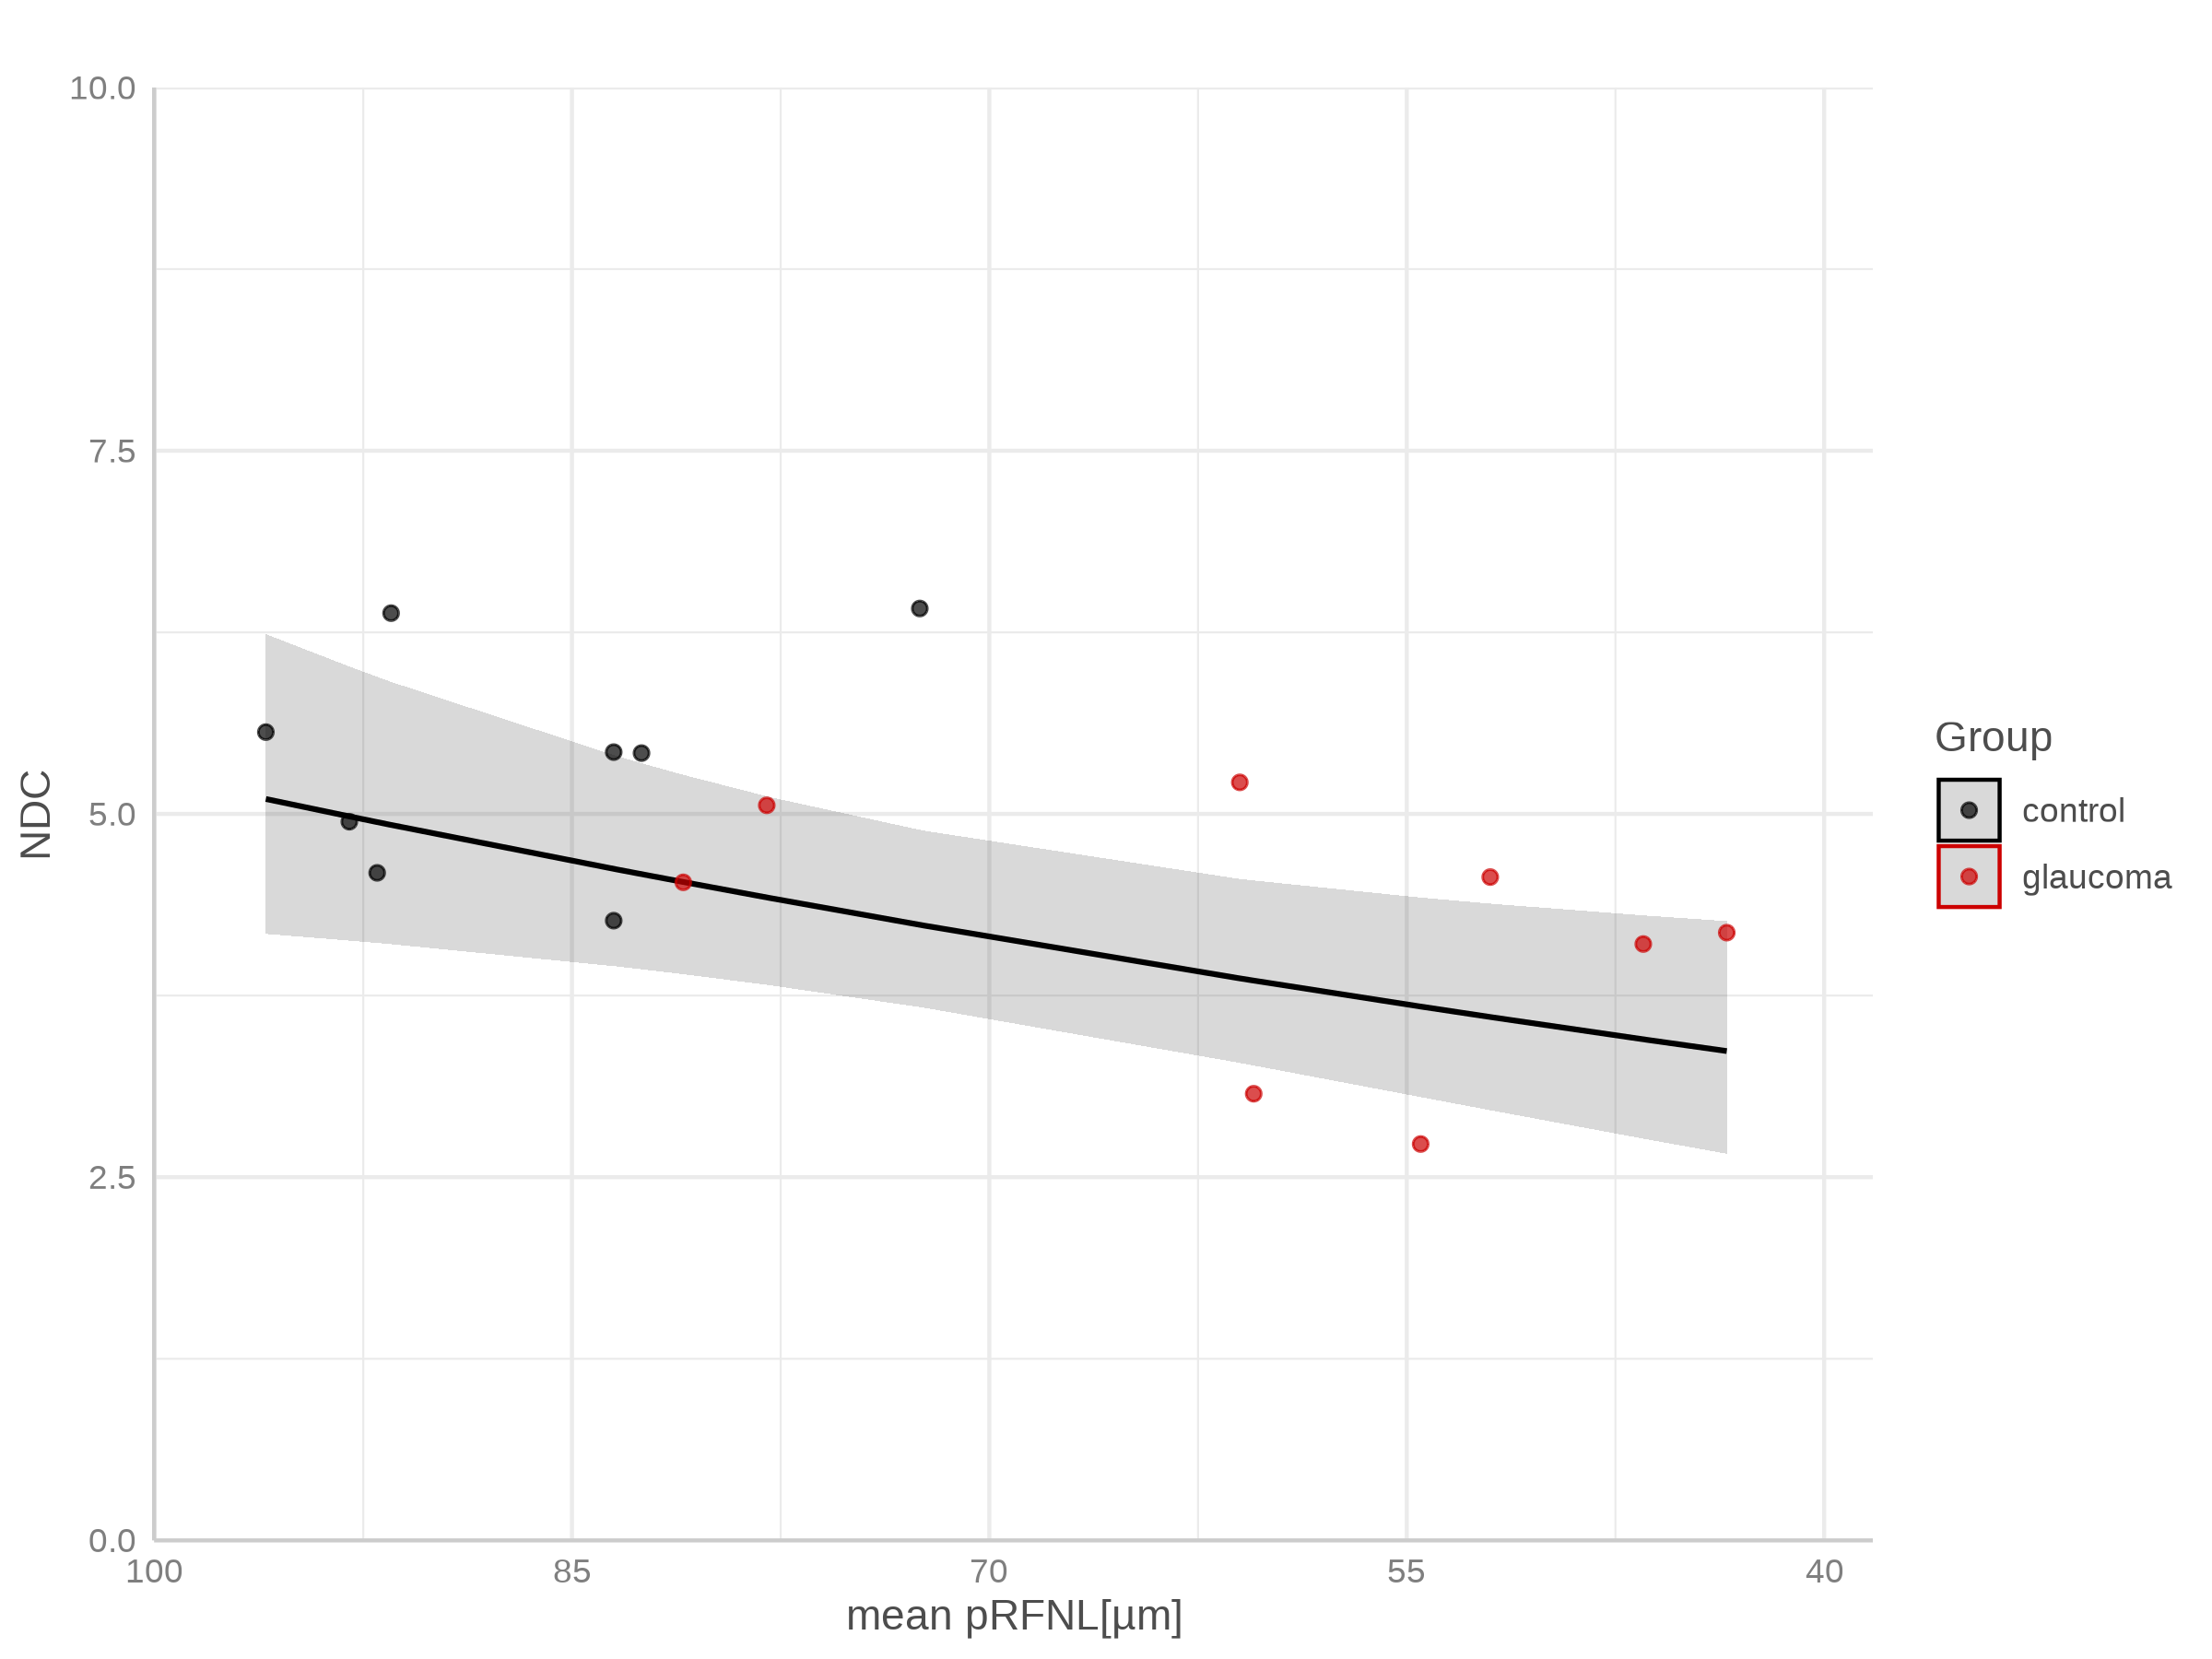

In [ ]:


# Create a reference grid
ref_grid <- ref_grid(model_bl_pRFNL_filtered)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
model_bl_pRFNL_filtered_grid <- regrid(ref_grid, transform = "response")


mn_pRFNL <- vf_df_pick %>% pull(no_scaled_pRFNL) %>% min(na.rm = TRUE)
mx_pRFNL <- vf_df_pick %>% pull(no_scaled_pRFNL) %>% max(na.rm = TRUE)

tr_pRFNL <- function(x) {
  (x + 1) * (mx_pRFNL - mn_pRFNL) / 2 + mn_pRFNL
}

inv_pRFNL <- function(x) {
  (x - mn_pRFNL) / (mx_pRFNL - mn_pRFNL) * 2 - 1
}


pRFNL_transform <- new_transform(
  name = "pRFNL",
  transform = function(x) -tr_pRFNL(x),
  inverse = function(x) -x,
  breaks = function(x) seq(inv_pRFNL(40), inv_pRFNL(100), length.out = 5)
)

building_removed_predict <- predict(model_bl_pRFNL_filtered, data = df_node_combined_pRFNL_filtered, allow.new.levels = TRUE, re.form = ~ (1 | PID), type = "response")

df_node_combined_pred <- df_node_combined_pRFNL_filtered %>%
  mutate(mean_connections = building_removed_predict) %>%
  group_by(PID, mean_pRFNL, group) %>%
  summarise(mean_connections = mean(mean_connections)) %>%
  ungroup()
df_node_combined_pred %>% head()

pred_effects_pRFNL <- ggemmeans(model_bl_pRFNL_filtered, terms = c("mean_pRFNL [all]"))
plot_pRFNL <- plot(pred_effects_pRFNL) +
    #geom_violin(aes(x = mean_pRFNL, y = mean_connections, group = PID, color = group), alpha = 0.2, data = df_node_combined_filtered) +
    geom_point(aes(x = mean_pRFNL, y = mean_connections, group = PID, color = group), alpha = 0.7, data = df_node_combined_pred) +
    scale_y_continuous(lim = c(0, 10), expand = c(0,0)) +
    labs(
      x = "mean pRFNL[µm]",
      y = "NDC",
      color = "Group",
      title = ""
    ) +
    #xlim(c(-1.1, 1.1)) +
    #scale_x_reverse(labels = function (x) round((x + 1) * (mx_pRFNL - mn_pRFNL) / 2 + mn_pRFNL)) +
    scale_x_continuous(transform = pRFNL_transform, limits = c(1.153, -1.2), expand = c(0, 0)) +
    scale_color_manual(values=c("black", "#CC0000", "gray", "#FF0000"))


model_bl_pRFNL_filtered %>% tidy() %>% gt() %>% capture.output() %>% IRdisplay::display_html()
plot_pRFNL


  


##### Node Worst MD Graph

Warning message in predict.merMod(model_bl_worstMD_filtered, data = df_node_combined_worstMD_filtered, :
“unused arguments ignored”
`summarise()` has grouped output by 'PID', 'worst_MD'. You can override using
the `.groups` argument.


PID,worst_MD,group,mean_connections
<fct>,<dbl>,<fct>,<dbl>
2002,0.8373923,control,4.907710
2005,0.8666167,control,5.404570
2006,0.2116898,glaucoma,4.455292
2007,-1.0000000,glaucoma,4.084072
2008,0.7804421,control,4.240594
2009,0.8598726,control,6.400481


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


effect,group,term,estimate,std.error,statistic,p.value
fixed,NA,(Intercept),0.9539263,0.09041389,10.550661,5.044082e-26
fixed,NA,worst_MD,0.1924050,0.08342360,2.306361,2.109045e-02
fixed,NA,building_locationinside,0.7965041,0.09985932,7.976262,1.508311e-15
ran_pars,hitObjectColliderName,sd__(Intercept),0.4699547,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.2064509,NA,NA,NA


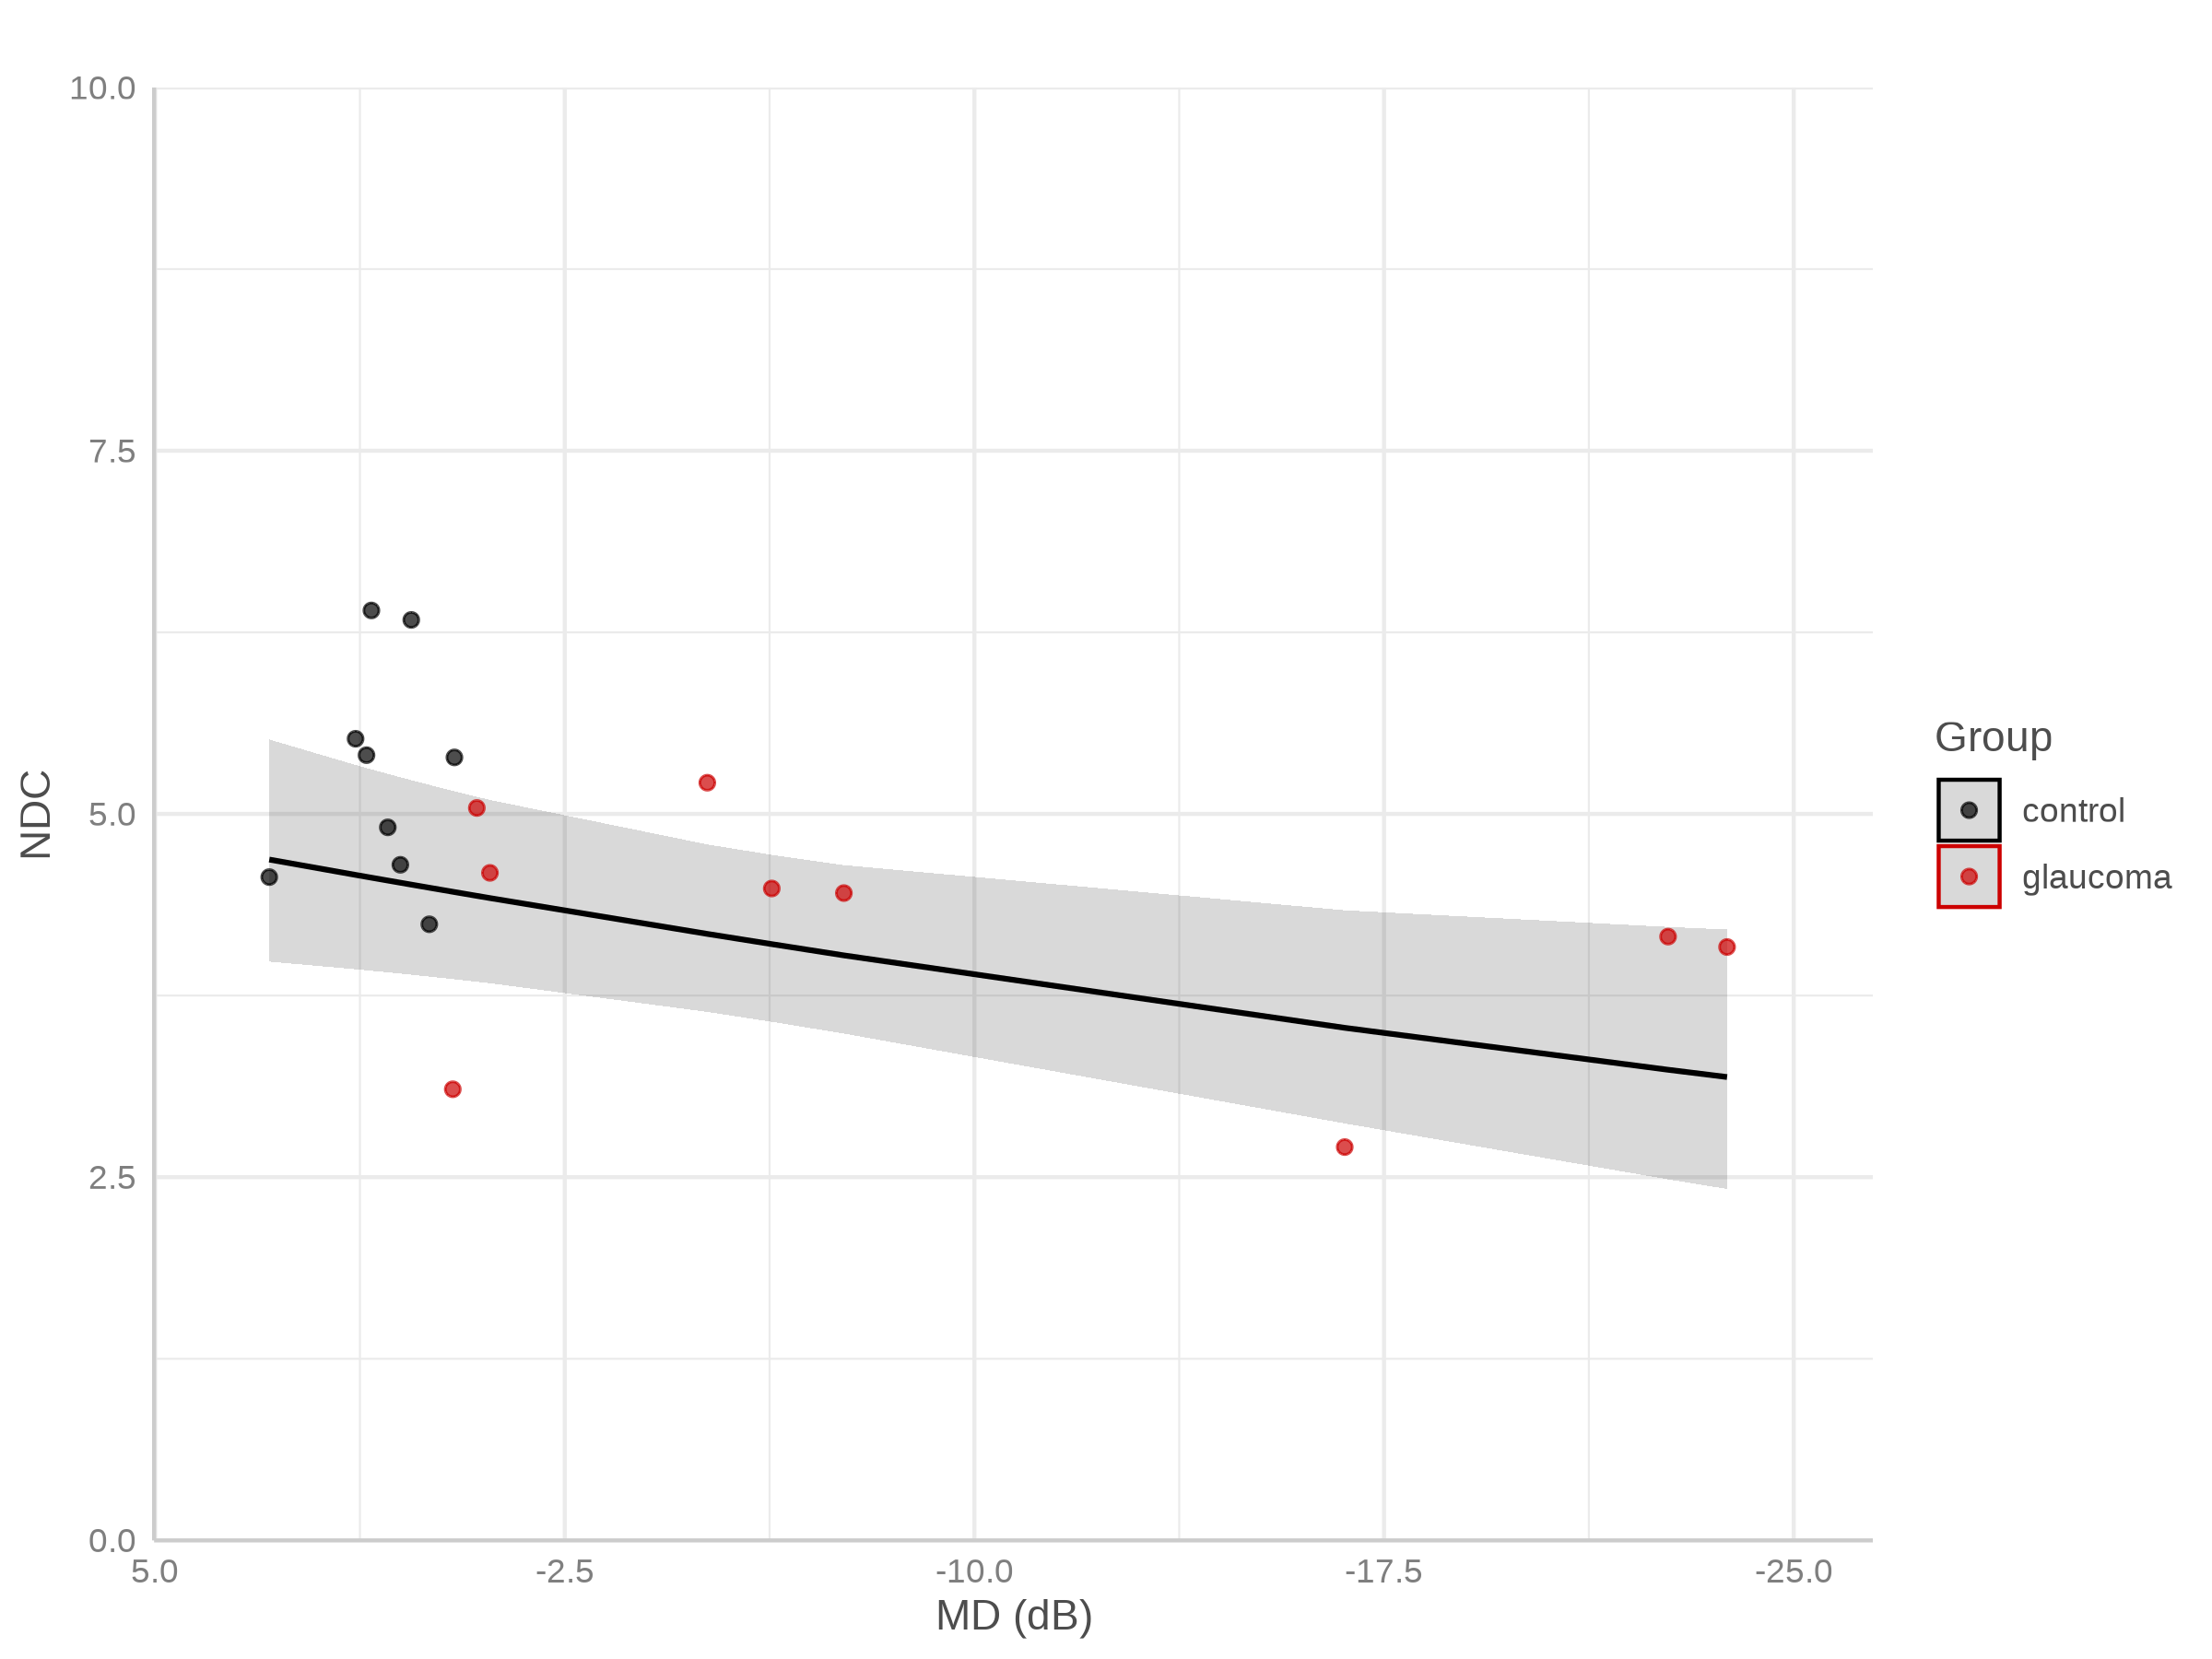

In [328]:
# Create a reference grid
ref_grid <- ref_grid(model_bl_worstMD_filtered)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
model_bl_worstMD_filtered_grid <- regrid(ref_grid, transform = "response")

mn_worstMD <- vf_df_pick %>% pull(unscaled_worst_MD) %>% min(na.rm = TRUE)
mx_worstMD <- vf_df_pick %>% pull(unscaled_worst_MD) %>% max(na.rm = TRUE)

tr_worstMD <- function(x) {
  (x + 1) * (mx_worstMD - mn_worstMD) / 2 + mn_worstMD
}

inv_worstMD <- function(x) {
  (x - mn_worstMD) / (mx_worstMD - mn_worstMD) * 2 - 1
}


worstMD_transform <- new_transform(
  name = "pRFNL",
  transform = function(x) -tr_worstMD(x),
  inverse = function(x) -x,
  breaks = function(x) seq(inv_worstMD(5), inv_worstMD(-25), length.out = 5)
)

building_removed_predict <- predict(model_bl_worstMD_filtered, data = df_node_combined_worstMD_filtered, allow.new.levels = TRUE, re.form = ~ (1 | PID), type = "response")

df_node_combined_pred <- df_node_combined_worstMD_filtered %>%
  mutate(mean_connections = building_removed_predict) %>%
  group_by(PID, worst_MD, group) %>%
  summarise(mean_connections = mean(mean_connections)) %>%
  ungroup()
df_node_combined_pred %>% head()



pred_effects <- ggemmeans(model_bl_worstMD_filtered, terms = c("worst_MD [all]"))
plot_MD_worst <- plot(pred_effects) +
    #geom_violin(aes(x = mean_pRFNL, y = mean_connections, group = PID, color = group), alpha = 0.2, data = df_node_combined_filtered) +
    geom_point(aes(x = worst_MD, y = mean_connections, group = PID, color = group), alpha = 0.7, data = df_node_combined_pred) +
    scale_y_continuous(lim = c(0, 10), expand = c(0,0)) +
    labs(
      x = "MD (dB)",
      y = "NDC",
      color = "Group",
      title = ""
    ) +
    #xlim(c(-1.1, 1.1)) +
    #scale_x_reverse(labels = function (x) round((x + 1) * (mx_pRFNL - mn_pRFNL) / 2 + mn_pRFNL)) +
    scale_x_continuous(transform = worstMD_transform, limits = c(1.158, -1.2), expand = c(0, 0)) +
    scale_color_manual(values=c("black", "#CC0000", "gray", "#FF0000"))
plot_MD_worst
  model_bl_worstMD_filtered %>% tidy() %>% gt() %>% capture.output() %>% IRdisplay::display_html()

##### Node Best MD Graph

Warning message in predict.merMod(model_bl_bestMD_filtered, data = df_node_combined_bestMD_filtered, :
“unused arguments ignored”
`summarise()` has grouped output by 'PID', 'best_MD'. You can override using
the `.groups` argument.


PID,best_MD,group,mean_connections
<fct>,<dbl>,<fct>,<dbl>
2002,0.8595556,control,4.905742
2005,0.8346667,control,5.401847
2006,0.6142222,glaucoma,4.470988
2007,-0.8106667,glaucoma,4.100696
2008,0.8115556,control,4.237213
2009,0.8515556,control,6.403114


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


effect,group,term,estimate,std.error,statistic,p.value
fixed,NA,(Intercept),1.0290168,0.08527684,12.066779,1.582057e-33
fixed,NA,mean_pRFNL,0.2077415,0.08359345,2.485141,1.295000e-02
fixed,NA,building_locationinside,0.7860460,0.09999460,7.860884,3.814305e-15
ran_pars,hitObjectColliderName,sd__(Intercept),0.4678982,NA,NA,NA
ran_pars,PID,sd__(Intercept),0.2117222,NA,NA,NA


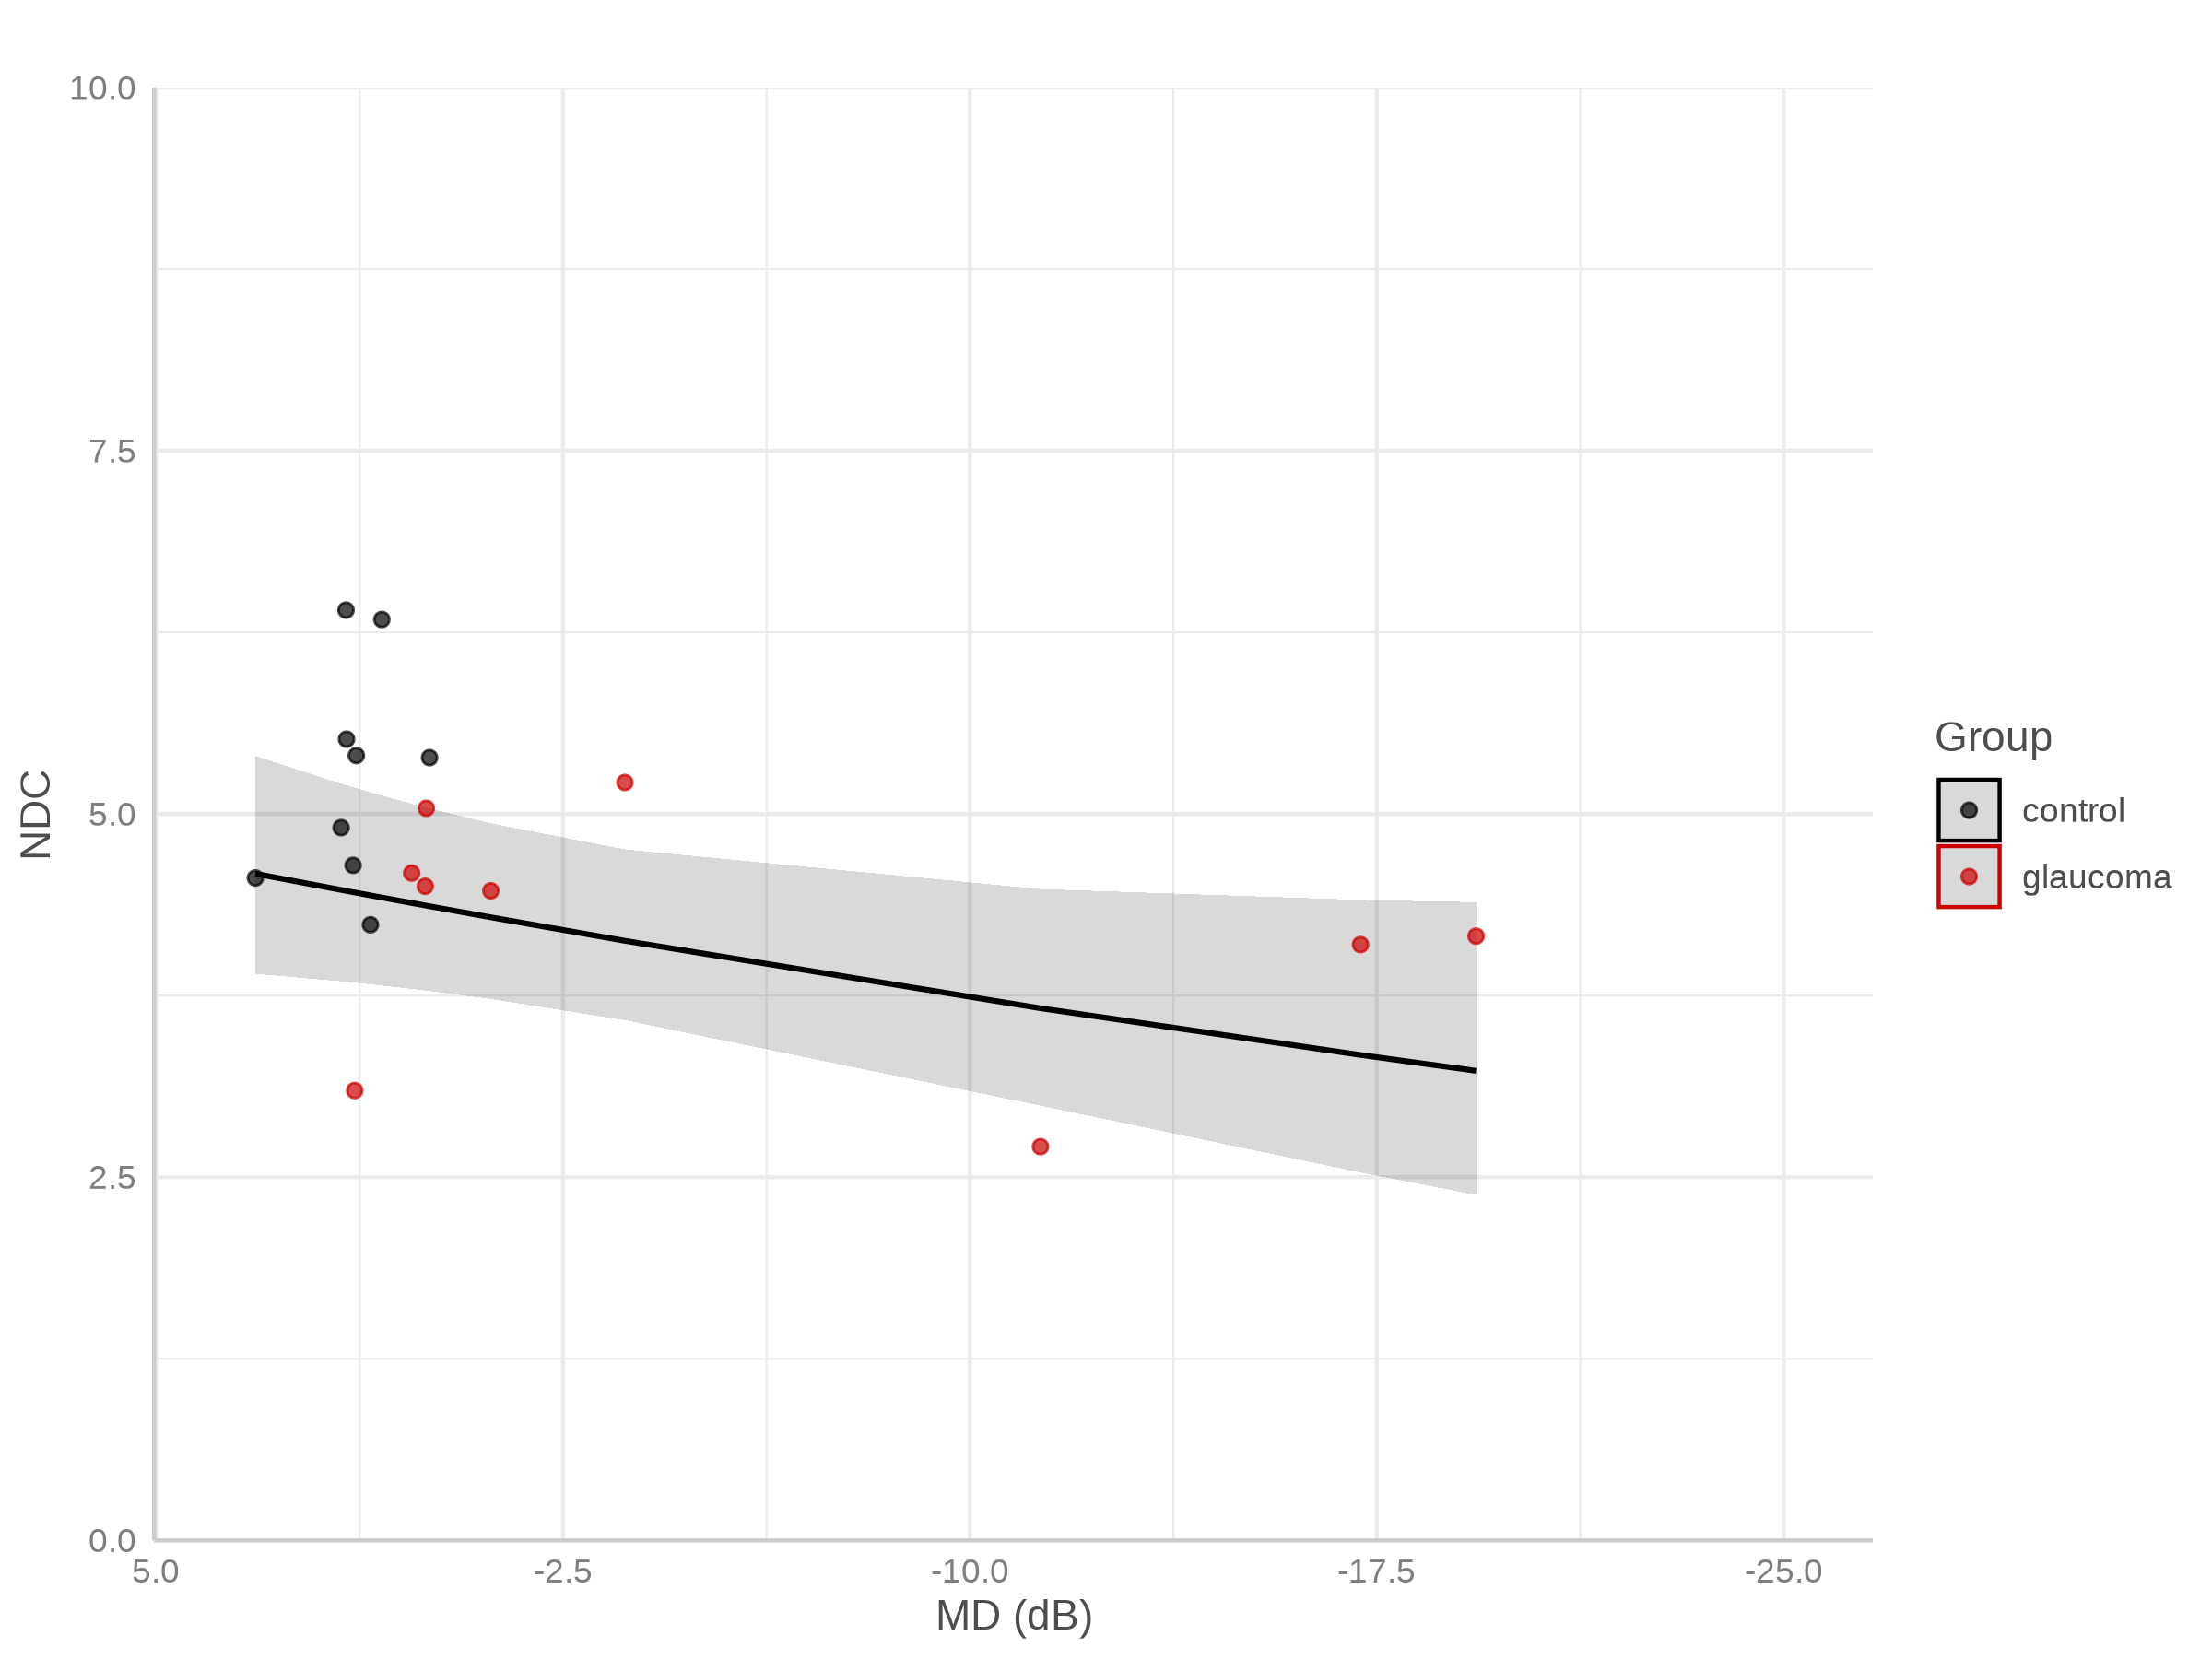

In [323]:
# Create a reference grid
ref_grid <- ref_grid(model_bl_bestMD_filtered)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
model_bl_bestMD_filtered_grid <- regrid(ref_grid, transform = "response")



mn_bestMD <- vf_df_pick %>% pull(unscaled_best_MD) %>% min(na.rm = TRUE)
mx_bestMD <- vf_df_pick %>% pull(unscaled_best_MD) %>% max(na.rm = TRUE)

tr_bestMD <- function(x) {
  (x + 1) * (mx_bestMD - mn_bestMD) / 2 + mn_bestMD
}

inv_bestMD <- function(x) {
  (x - mn_bestMD) / (mx_bestMD - mn_bestMD) * 2 - 1
}


bestMD_transform <- new_transform(
  name = "pRFNL",
  transform = function(x) -tr_bestMD(x),
  inverse = function(x) -x,
  breaks = function(x) seq(inv_bestMD(5), inv_bestMD(-25), length.out = 5)
)

building_removed_predict <- predict(model_bl_bestMD_filtered, data = df_node_combined_bestMD_filtered, allow.new.levels = TRUE, re.form = ~ (1 | PID), type = "response")

df_node_combined_pred <- df_node_combined_bestMD_filtered %>%
  mutate(mean_connections = building_removed_predict) %>%
  group_by(PID, best_MD, group) %>%
  summarise(mean_connections = mean(mean_connections)) %>%
  ungroup()
df_node_combined_pred %>% head()

pred_effects <- ggemmeans(model_bl_bestMD_filtered, terms = c("best_MD [all]"))
plot_best_MD <- plot(pred_effects) +
    geom_point(aes(x = best_MD, y = mean_connections, group = PID, color = group), alpha = 0.7, data = df_node_combined_pred) +
    scale_y_continuous(lim = c(0, 10), expand = c(0,0)) +
    labs(
      x = "MD (dB)",
      y = "NDC",
      color = "Group",
      title = "",
    ) +
    #xlim(c(-1.1, 1.1)) +
    #scale_x_reverse(labels = function (x) round((x + 1) * (mx_pRFNL - mn_pRFNL) / 2 + mn_pRFNL)) +
    scale_x_continuous(transform = bestMD_transform, limits = c(1.166, -1.65), expand = c(0, 0)) +
    scale_color_manual(values=c("black", "#CC0000", "gray", "#FF0000"))
plot_best_MD
  model_bl_pRFNL_filtered %>% tidy() %>% gt() %>% capture.output() %>% IRdisplay::display_html()

##### Combination of visual function plots

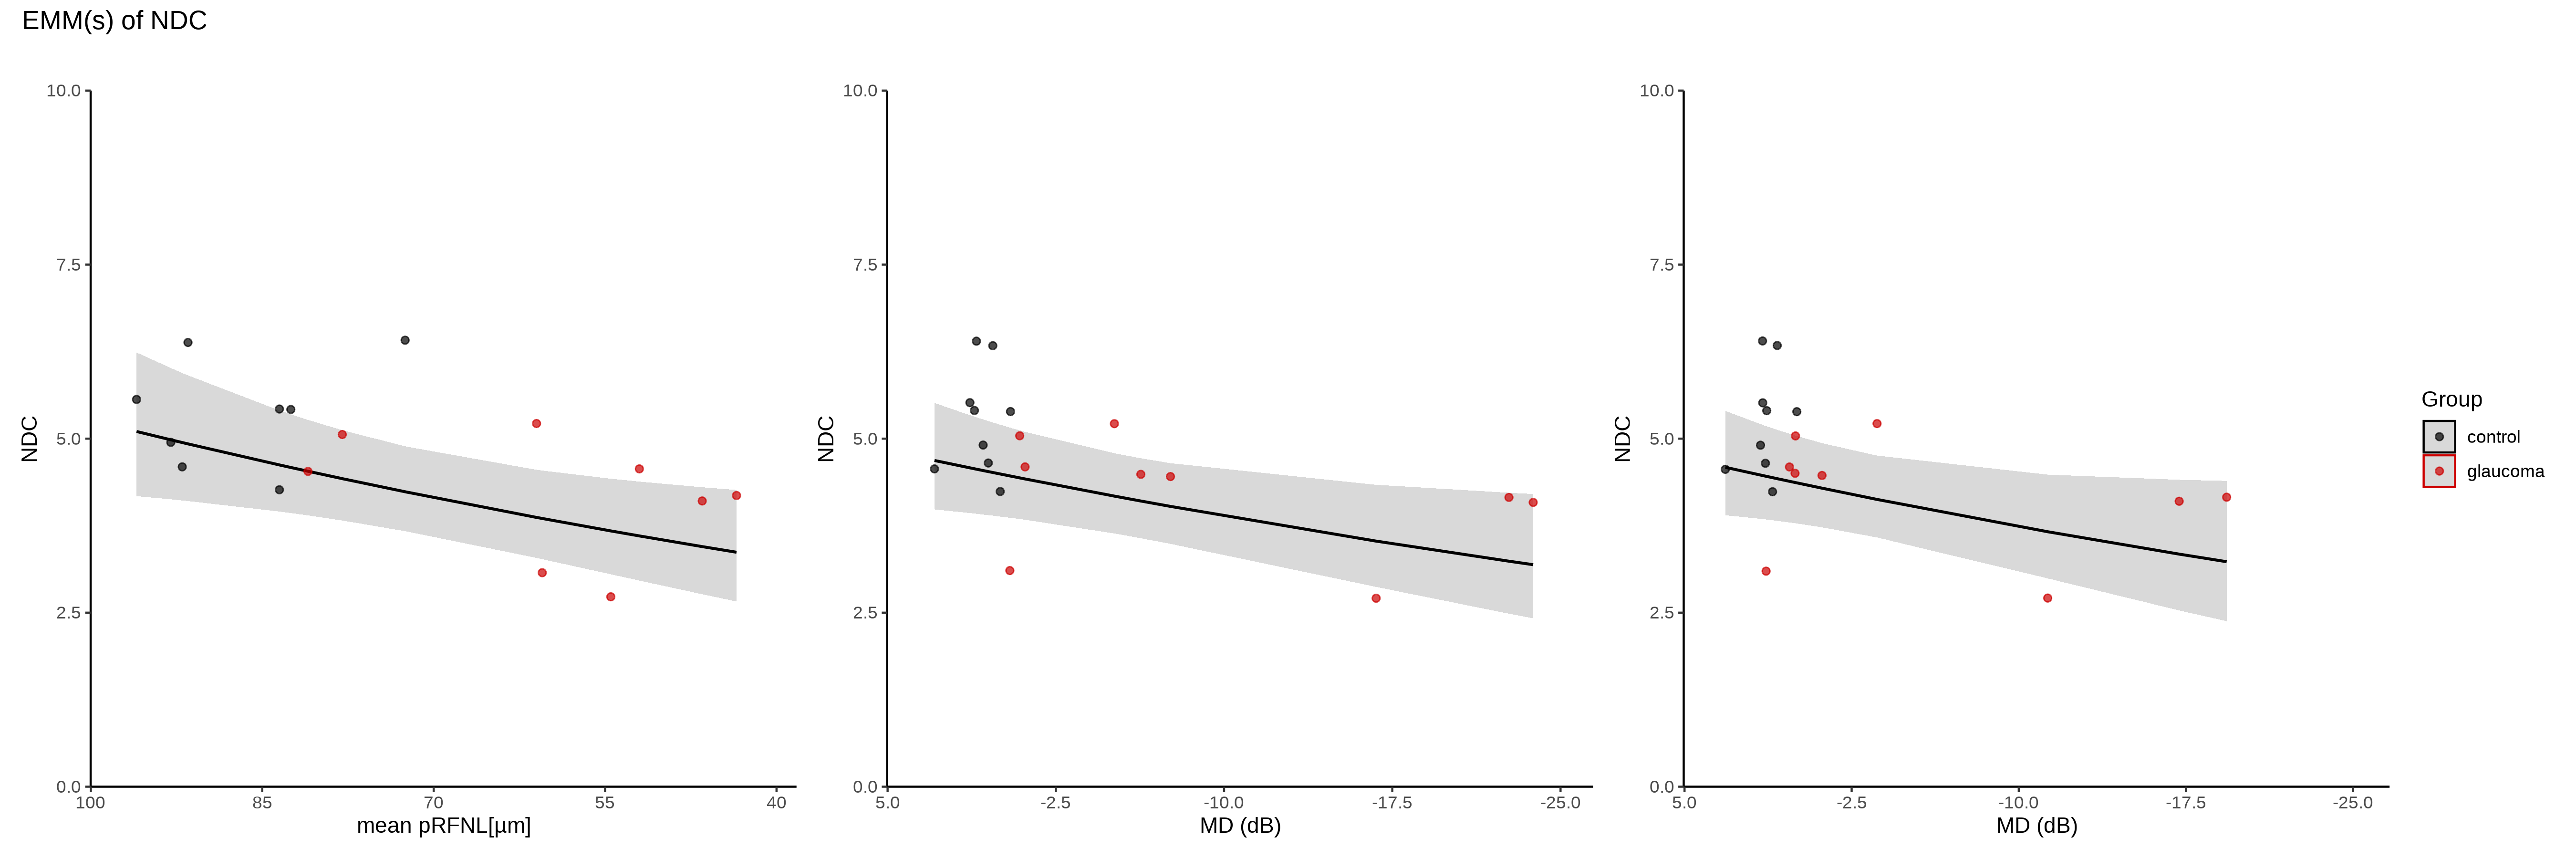

In [330]:
options(repr.plot.width=18, repr.plot.height=6, repr.plot.res = 300)
(plot_pRFNL + 
    plot_MD_worst + 
    plot_best_MD + 
    plot_layout(guides = 'collect') +
    plot_annotation(title = 'EMM(s) of NDC')
    ) & theme_classic()
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)


##### Unnamed Playground

In [84]:
node_combined_model_00 <- glmer(mean_connections ~ (1 | PID) +  (1 | hitObjectColliderName), data = df_node_combined, family = poisson())
node_combined_model_0 <- glmer(mean_connections ~ mean_pRFNL + (1 | PID) + (1 | hitObjectColliderName), data = df_node_combined, family = poisson())
node_combined_model_inter <- glmer(mean_connections ~ mean_pRFNL + building_location + (1 | PID) + (1 | hitObjectColliderName), data = df_node_combined, family = poisson())
node_combined_model_full <- glmer(mean_connections ~ mean_pRFNL + building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df_node_combined, family = poisson())
node_combined_model_interact <- glmer(mean_connections ~ mean_pRFNL + building_location * group + (1 | PID) + (1 | hitObjectColliderName), data = df_node_combined, family = poisson())

In [75]:
anova(node_combined_model_0)
anova(node_combined_model_0, node_combined_model_inter)
anova(node_combined_model_inter, node_combined_model_full)
anova(node_combined_model_full, node_combined_model_interact)
r2_nakagawa(node_combined_model_0)
r2_nakagawa(node_combined_model_inter)
r2_nakagawa(node_combined_model_full)
node_combined_model_full

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
exp(mean_pRFNL),1,5.217402,5.217402,5.217402


,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
node_combined_model_0,4,5465.115,5485.495,-2728.558,5457.115,NA,NA,NA
node_combined_model_inter,5,5413.834,5439.310,-2701.917,5403.834,53.28077,1,2.891225e-13


,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
node_combined_model_inter,5,5413.834,5439.310,-2701.917,5403.834,NA,NA,NA
node_combined_model_full,6,5413.534,5444.105,-2700.767,5401.534,2.300077,1,0.1293675


,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
node_combined_model_full,6,5413.534,5444.105,-2700.767,5401.534,NA,NA,NA
node_combined_model_interact,7,5415.301,5450.966,-2700.650,5401.301,0.2336914,1,0.6288001


# R2 for Mixed Models

  Conditional R2: 0.687
     Marginal R2: 0.026

# R2 for Mixed Models

  Conditional R2: 0.693
     Marginal R2: 0.268

# R2 for Mixed Models

  Conditional R2: 0.691
     Marginal R2: 0.276

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: poisson  ( log )
Formula: mean_connections ~ exp(mean_pRFNL) + building_location + group +  
    (1 | PID) + (1 | hitObjectColliderName)
   Data: df_node_combined
      AIC       BIC    logLik -2*log(L)  df.resid 
 5413.534  5444.105 -2700.767  5401.534      1200 
Random effects:
 Groups                Name        Std.Dev.
 hitObjectColliderName (Intercept) 0.4678  
 PID                   (Intercept) 0.2002  
Number of obs: 1206, groups:  hitObjectColliderName, 115; PID, 16
Fixed Effects:
            (Intercept)          exp(mean_pRFNL)  building_locationinside  
                1.15367                  0.02683                  0.78620  
          groupglaucoma  
               -0.26829  

effect,term,estimate,std.error,statistic,p.value
fixed,(Intercept),1.15366856,0.20684327,5.5775010,2.439984e-08
fixed,exp(mean_pRFNL),0.02682709,0.09560047,0.2806168,7.790044e-01
fixed,building_locationinside,0.78619949,0.08538494,9.2077064,3.331676e-20
fixed,groupglaucoma,-0.26829374,0.14534243,-1.8459423,6.490058e-02


Warning message:
“Removed 310 rows containing missing values or values outside the scale range
(`geom_point()`).”


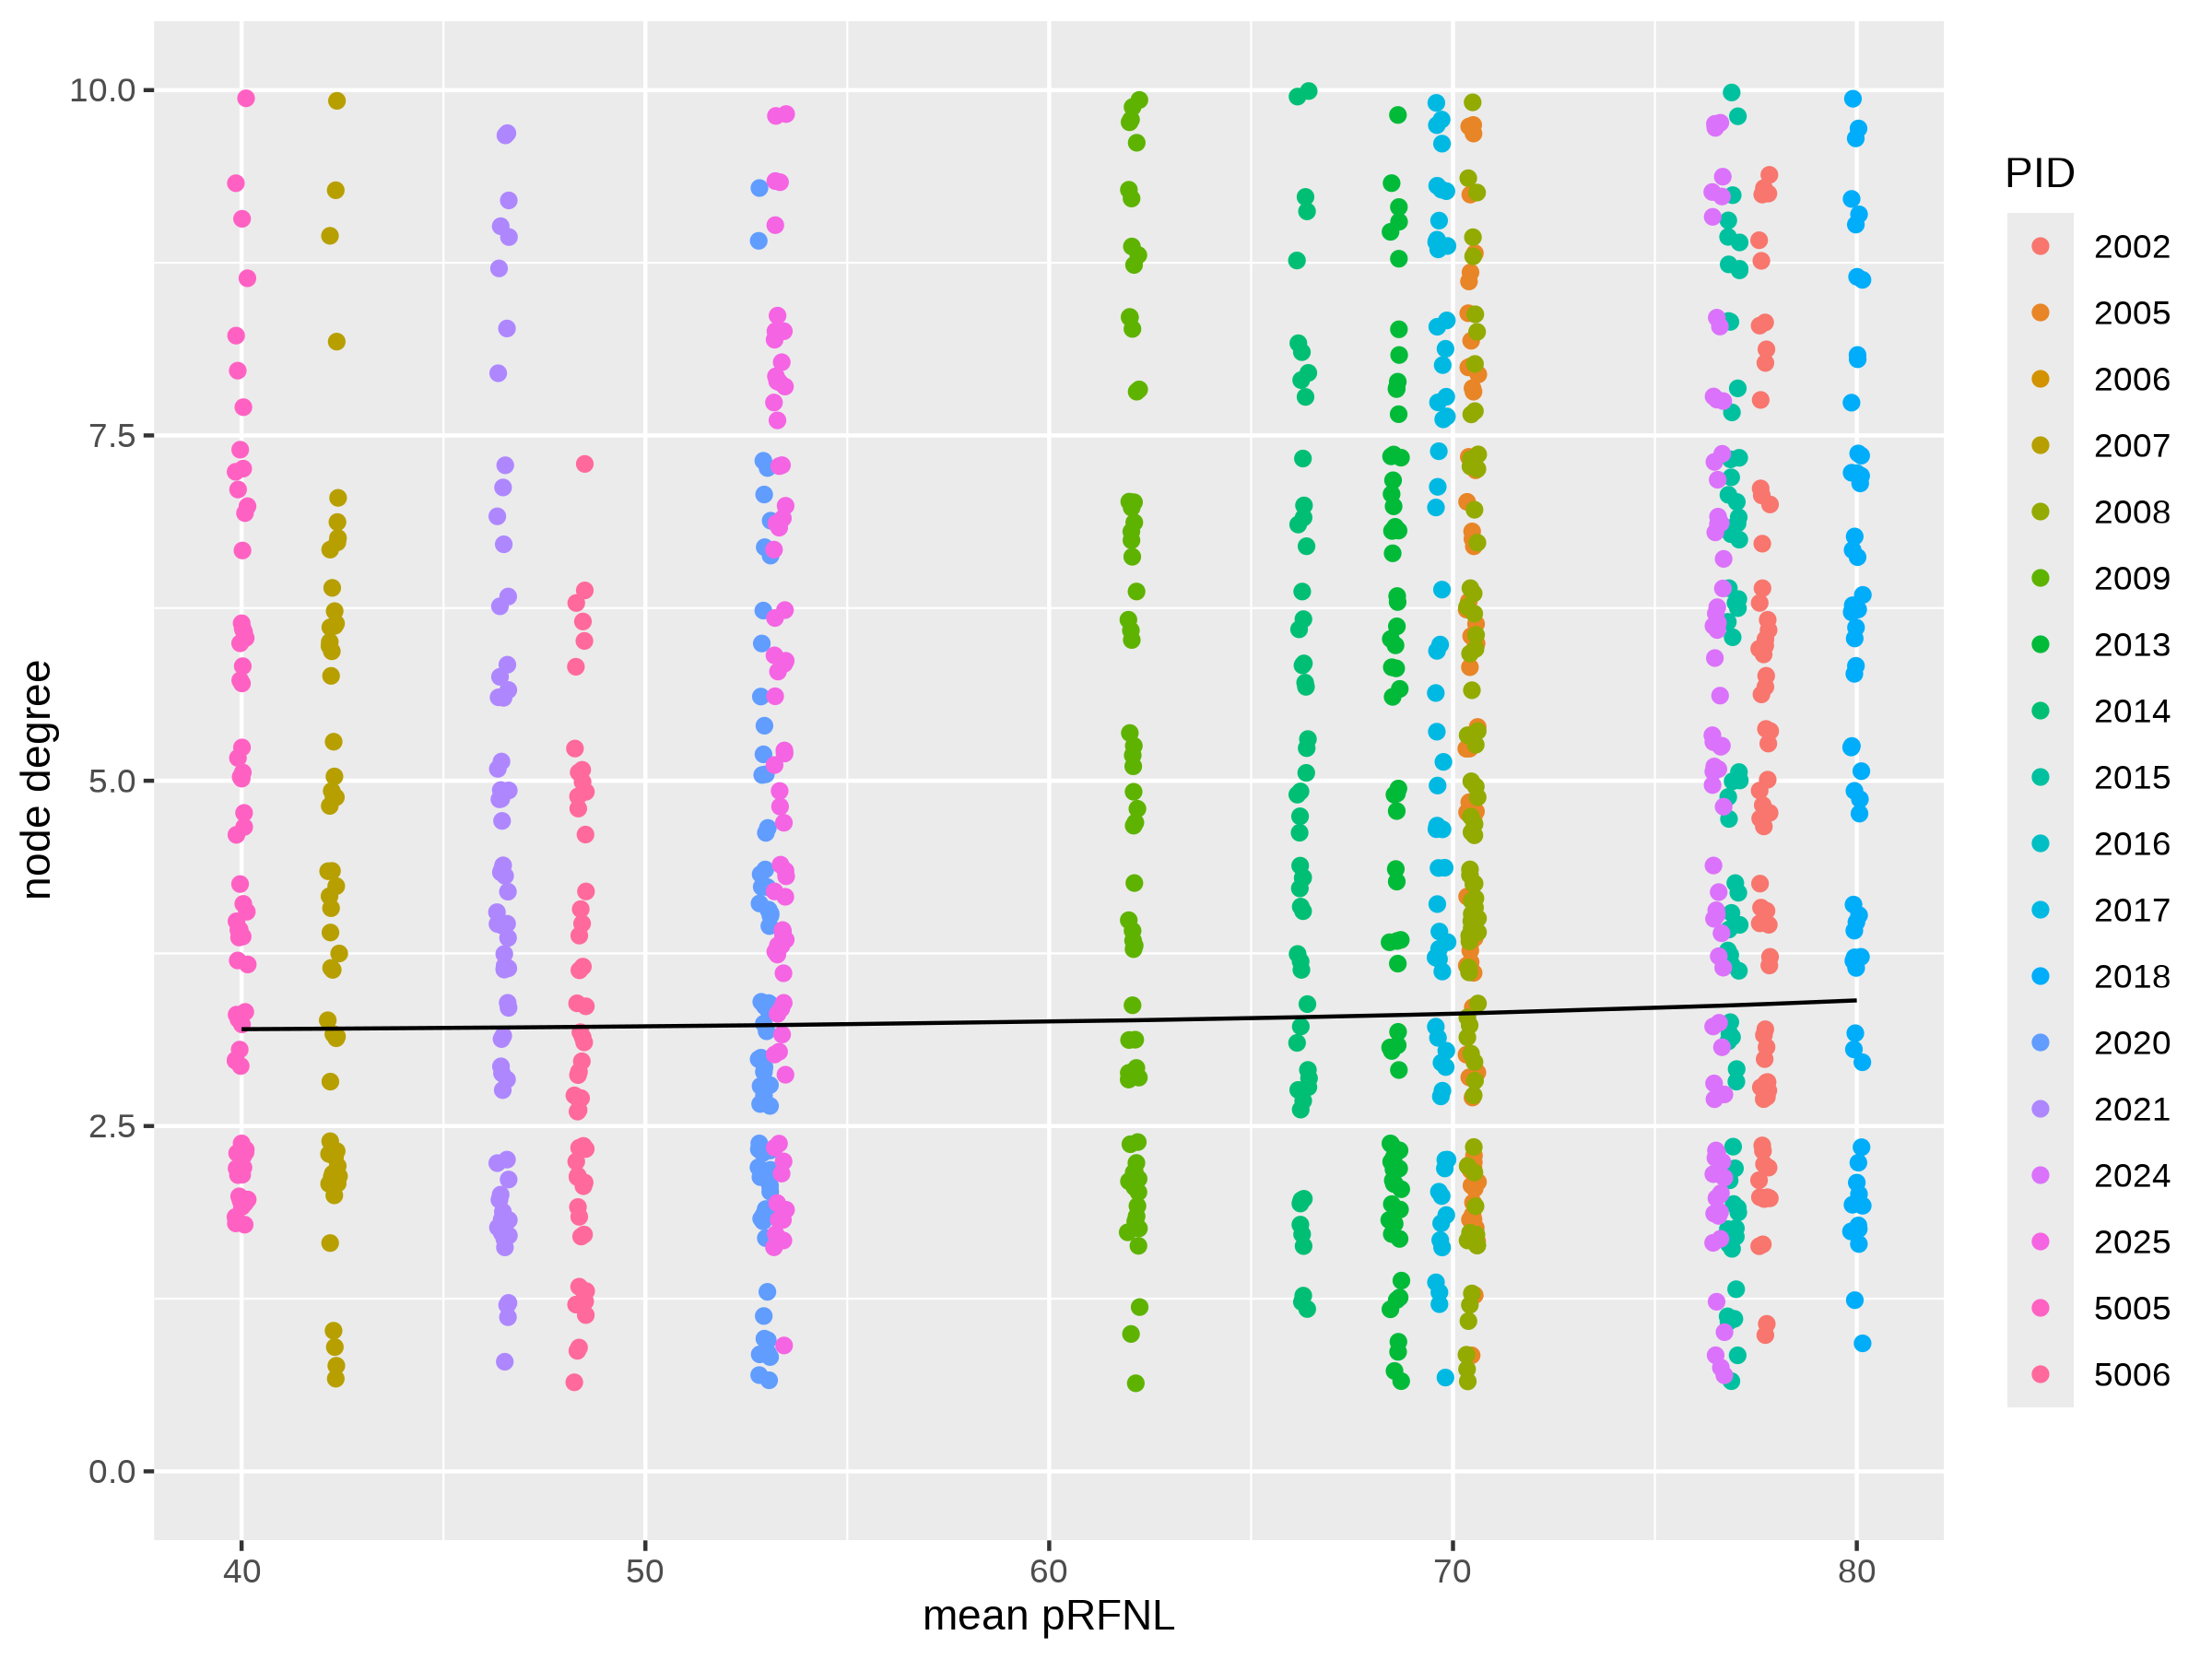

In [80]:
node_combined_model_full %>% tidy_quasi() %>% gt() %>% capture.output() %>% IRdisplay::display_html()
predicted_df_node_combined <- ggpredict(node_combined_model_full, terms = c("mean_pRFNL"))
ggplot(predicted_df_node_combined, aes(x = x * 20 + 60, y = predicted)) +
    geom_jitter(data = df_node_combined, aes(x = mean_pRFNL * 20 + 60, y = mean_connections, color = PID)) +
    geom_line() + 
    labs(x = "mean pRFNL", y = "node degree") +
    ylim(0, 10)

In [78]:
ref_grid <- ref_grid(node_model_full)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)
emm %>% pairs()
emm
emmeans(new_grid, ~ building_location)

 contrast           estimate    SE  df z.ratio p.value
 control - glaucoma     1.23 0.443 Inf   2.785  0.0054

Results are averaged over the levels of: building_location 

 group    rate    SE  df asymp.LCL asymp.UCL
 control  5.22 0.450 Inf      4.34      6.11
 glaucoma 3.99 0.347 Inf      3.31      4.67

Results are averaged over the levels of: building_location 
Confidence level used: 0.95 

 building_location rate    SE  df asymp.LCL asymp.UCL
 outside           2.86 0.229 Inf      2.41      3.31
 inside            6.35 0.564 Inf      5.24      7.46

Results are averaged over the levels of: group 
Confidence level used: 0.95 

#### Model Summary

In [111]:
get_model_summary <- function(model_0, model_inter, model_full) {

    ## model 0 summary
    model_0_mean_summary <- model_0 %>% tidy() %>% pull(estimate)
    model_0_std_summary <- model_0 %>% tidy() %>% pull(std.error)

    model_0_intercept <- c(
        model_0_mean_summary[1] %>% round(3),
        (model_0_mean_summary[1] - 1.96 * model_0_std_summary[1]) %>% round(3),
        (model_0_mean_summary[1] + 1.96 * model_0_std_summary[1]) %>% round(3)
    )

    model_0_corr_var <- model_0 %>% VarCorr() %>% as_tibble() %>% pull()
    model_0_building_var <- model_0_corr_var[1]^2 %>% round(3)
    model_0_PID_var <- model_0_corr_var[2]^2 %>% round(3)
    model_0_res_var <- model_0_corr_var[3]^2 %>% round(3)
    if (is.na(model_0_res_var)) {
        model_0_res_var <- "—"
    }
    model_0_intercept_mean <- model_0_intercept[1]
    model_0_intercept_lowCL <- model_0_intercept[2]
    model_0_intercept_highCL <- model_0_intercept[3]
    model_0_icc <- model_0 %>% icc(by_group = TRUE) %>% pull(ICC)
    model_0_icc_building <- model_0_icc[1] %>% round(4) * 100
    model_0_icc_PID <- model_0_icc[2] %>% round(4) * 100
    model_0_AIC <- model_0 %>% AIC() %>% round(1)

    model_null <- list(
        "*b* [95% CI]",
        str_interp(
            "${model_0_intercept_mean} [${model_0_intercept_lowCL}, ${model_0_intercept_highCL}]"
        ),
        "—",
        "—",
        "$\\sigma^2$",
        model_0_building_var,
        model_0_PID_var,
        model_0_res_var,
        "—", "—",
        model_0_icc_building, model_0_icc_PID, 
        model_0_AIC
    )

    ## model inter summary
    model_inter_mean_summary <- model_inter %>% tidy() %>% pull(estimate)
    model_inter_std_summary <- model_inter %>% tidy() %>% pull(std.error)

    model_inter_intercept <- c(
        model_inter_mean_summary[1] %>% round(3),
        (model_inter_mean_summary[1] - 1.96 * model_inter_std_summary[1]) %>% round(3),
        (model_inter_mean_summary[1] + 1.96 * model_inter_std_summary[1]) %>% round(3)
    )

    model_inter_building <- c(
        model_inter_mean_summary[2] %>% round(3),
        (model_inter_mean_summary[2] - 1.96 * model_inter_std_summary[2]) %>% round(3),
        (model_inter_mean_summary[2] + 1.96 * model_inter_std_summary[2]) %>% round(3)
    )

    model_inter_corr_var <- model_inter %>% VarCorr() %>% as_tibble() %>% pull()
    model_inter_building_var <- model_inter_corr_var[1]^2 %>% round(3)
    model_inter_PID_var <- model_inter_corr_var[2]^2 %>% round(3)
    model_inter_res_var <- model_inter_corr_var[3]^2 %>% round(3)
    if (is.na(model_inter_res_var)) {
        model_inter_res_var <- "—"
    }
    model_inter_icc <- model_inter %>% icc(by_group = TRUE) %>% pull(ICC)
    model_inter_icc_building <- model_inter_icc[1] %>% round(4) * 100
    model_inter_icc_PID <- model_inter_icc[2] %>% round(4) * 100
    model_inter_nakagawa <- model_inter %>% r2_nakagawa()
    model_inter_nakagawa_marginal <- model_inter_nakagawa$R2_marginal %>% unname() %>% round(4) * 100
    model_inter_nakagawa_conditional <- model_inter_nakagawa$R2_conditional %>% unname() %>% round(4) * 100
    model_inter_AIC <- model_inter %>% AIC() %>% round(1)


    model_inter_summary <- list(
        "*b* [95% CI]",
        str_interp(
            "${model_inter_intercept[1]} [${model_inter_intercept[2]}, ${model_inter_intercept[3]}]"
        ),
        str_interp(
            "${model_inter_building[1]} [${model_inter_building[2]}, ${model_inter_building[3]}]"
        ),
        "—",
        "$\\sigma^2$",
        model_inter_building_var,
        model_inter_PID_var,
        model_inter_res_var,
        model_inter_nakagawa_marginal, model_inter_nakagawa_conditional,
        model_inter_icc_building, model_inter_icc_PID, 
        model_inter_AIC
    )


    ## model full summary
    model_full_mean_summary <- model_full %>% tidy() %>% pull(estimate)
    model_full_std_summary <- model_full %>% tidy() %>% pull(std.error)

    model_full_intercept <- c(
        model_full_mean_summary[1] %>% round(3),
        (model_full_mean_summary[1] - 1.96 * model_full_std_summary[1]) %>% round(3),
        (model_full_mean_summary[1] + 1.96 * model_full_std_summary[1]) %>% round(3)
    )

    model_full_building <- c(
        model_full_mean_summary[2] %>% round(3),
        (model_full_mean_summary[2] - 1.96 * model_full_std_summary[2]) %>% round(3),
        (model_full_mean_summary[2] + 1.96 * model_full_std_summary[2]) %>% round(3)
    )

    model_full_peripheral <- c(
        model_full_mean_summary[3] %>% round(3),
        (model_full_mean_summary[3] - 1.96 * model_full_std_summary[3]) %>% round(3),
        (model_full_mean_summary[3] + 1.96 * model_full_std_summary[3]) %>% round(3)
    )

    model_full_central <- c(
        model_full_mean_summary[4] %>% round(3),
        (model_full_mean_summary[4] - 1.96 * model_full_std_summary[4]) %>% round(3),
        (model_full_mean_summary[4] + 1.96 * model_full_std_summary[4]) %>% round(3)
    )

    model_full_corr_var <- model_full %>% VarCorr() %>% as_tibble() %>% pull()
    model_full_building_var <- model_full_corr_var[1]^2 %>% round(3)
    model_full_PID_var <- model_full_corr_var[2]^2 %>% round(3)
    model_full_res_var <- model_full_corr_var[3]^2 %>% round(3)
    if (is.na(model_full_res_var)) {
        model_full_res_var <- "—"
    }
    model_full_icc <- model_full %>% icc(by_group = TRUE) %>% pull(ICC)
    model_full_icc_building <- model_full_icc[1] %>% round(4) * 100 
    model_full_icc_PID <- model_full_icc[2] %>% round(4) * 100
    model_full_nakagawa <- model_full %>% r2_nakagawa()
    model_full_nakagawa_marginal <- model_full_nakagawa$R2_marginal %>% unname() %>% round(4) * 100
    model_full_nakagawa_conditional <- model_full_nakagawa$R2_conditional %>% unname() %>% round(4) * 100
    model_full_AIC <- model_full %>% AIC() %>% round(1)


    model_full_summary <- list(
        "*b* [95% CI]",
        str_interp(
            "${model_full_intercept[1]} [${model_full_intercept[2]}, ${model_full_intercept[3]}]"
        ),
        str_interp(
            "${model_full_building[1]} [${model_full_building[2]}, ${model_full_building[3]}]"
        ),
        str_interp(
            "${model_full_peripheral[1]} [${model_full_peripheral[2]}, ${model_full_peripheral[3]}]"
        ),
        "$\\sigma^2$",
        model_full_building_var,
        model_full_PID_var,
        model_full_res_var,
        model_full_nakagawa_marginal, model_full_nakagawa_conditional,
        model_full_icc_building, model_full_icc_PID, 
        model_full_AIC
    )


    list(
        model_null = model_null,
        model_inter_summary = model_inter_summary,
        model_full_summary = model_full_summary
    )
}

In [122]:
dwell_time_model_summaries <- get_model_summary(model_0, model_inter, model_full)
node_model_summaries <- get_model_summary(node_model_0, node_model_inter, node_model_full)

#### GT Table Generation

In [124]:
dt <- tibble(
    model_name = c(
        "***fixed effects***",
        "intercept",
        "region (inside)",
        "group (glaucoma)",
        "***random effects***",
        "building",
        "participant",
        "observation-level<br>&nbsp;&nbsp;(distribution-specific)",
        "$R^2_{GLMM(m)}$ (%)",
        "$R^2_{GLMM(c)}$ (%)",
        "$ICC_{[Building]}$ (%)",
        "$ICC_{[Participant]}$ (%)",
        "$AIC$"
    ),
    # dwell time models
    dw_null_model = dwell_time_model_summaries$model_null,
    dw_inter_model = dwell_time_model_summaries$model_inter_summary,
    dw_full_model = dwell_time_model_summaries$model_full_summary,
    # node models
    node_null_model = node_model_summaries$model_null,
    node_inter_model = node_model_summaries$model_inter_summary,
    node_full_model = node_model_summaries$model_full_summary
)

dt %>% gt() %>% 
  tab_spanner(
    label = md("**Dwell Time Models (inverse-link)<br>Gamma Mixed Models**"),
    columns = starts_with("dw"),
    id = "dwell_time_models"
  ) %>%
  tab_spanner(
    label = md("**NDC Models (log-link)<br>Poisson Mixed Models**"),
    columns = starts_with("node")
  ) %>%
  cols_label(
    model_name = md("**Model Name**"),
    dw_null_model = md("**Null Model**"),
    dw_inter_model = md("**Intermediate Model**"),
    dw_full_model = md("**Full Model**"),
    node_null_model = md("**Null Model**"),
    node_inter_model = md("**Intermediate Model**"),
    node_full_model = md("**Full Model**")
  ) %>%
  tab_style(
    style = cell_borders(
      sides = c("right", "left"),
      color = "black",
      weight = px(2)
    ),
    locations = cells_column_spanners(
      "dwell_time_models"
    )
  ) %>%
  tab_style(
    style = cell_borders(
      sides = "right",
      color = "black",
      weight = px(2)
    ),
    locations = cells_column_labels(
      "dw_full_model"
    )
  ) %>%
   tab_style(
    style = cell_borders(
      sides = "right",
      color = "black",
      weight = px(2)
    ),
    locations = cells_body(
      "dw_full_model"
    )
  ) %>%
  tab_style(
    style = cell_borders(
      sides = "left",
      color = "black",
      weight = px(2)
    ),
    locations = cells_column_labels(
      "dw_null_model"
    )
  ) %>%
   tab_style(
    style = cell_borders(
      sides = "left",
      color = "black",
      weight = px(2)
    ),
    locations = cells_body(
      "dw_null_model"
    )
  ) %>%
  cols_width(everything() ~ px(200)) %>%
  fmt_markdown() %>%
  gtsave("glaucoma_model_summaries.html")
  #capture.output() %>% 
  #IRdisplay::display_html()

In [137]:
anova(model_full, model_inter)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_inter,5,-1854.464,-1826.907,932.2321,-1864.464,NA,NA,NA
model_full,7,-1865.454,-1826.873,939.7269,-1879.454,14.98971,2,0.0005559382


#### Playground

In [18]:
df_summary <- df %>%
    group_by(group) %>%
    summarise(
        med_med = mean(median_clusterDuration),
    ) %>%
    ungroup()
df %>% summarise(med = mean(median_clusterDuration))
df_summary

med
<dbl>
0.4858801


group,med_med
<fct>,<dbl>
control,0.4713076
peripheral,0.5561940
central,0.4317396


In [8]:
model
library(car)
anova(model)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( inverse )
Formula: median_clusterDuration ~ building_location + group + (1 | PID) +  
    (1 | hitObjectColliderName)
   Data: df
       AIC        BIC     logLik  -2*log(L)   df.resid 
-1865.4538 -1826.8732   939.7269 -1879.4538       1822 
Random effects:
 Groups                Name        Std.Dev.
 hitObjectColliderName (Intercept) 0.2845  
 PID                   (Intercept) 0.1202  
 Residual                          0.3688  
Number of obs: 1829, groups:  hitObjectColliderName, 127; PID, 24
Fixed Effects:
            (Intercept)  building_locationinside             groupcontrol  
                 2.6867                  -0.3545                  -0.1874  
        groupperipheral  
                -0.4871  

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
building_location,1,3.598557,3.598557,26.46256
group,2,5.930017,2.965008,21.80367


In [35]:
# Create a reference grid
ref_grid <- ref_grid(model_full)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ groupT)
pairs(emm, adjust = "tukey")
emm_building <- emmeans(new_grid, ~ building_location)
emm_eff <- emmeans(model_full, ~ groupT)
emm_building_eff <- emmeans(model_full, ~ building_location)

VarCorr(model_full)
full_var <- as_tibble(VarCorr(model_full)) %>% pull(sdcor)
full_sd <- sqrt(sum(full_var^2))
eff_size(emm_eff, sigma = full_sd, edf = 1822)

# View results
summary(emm, level = 0.95)
emm_table_pairs <- pairs(emm_building, adjust = "tukey") %>% summary()
emm_table_pairs
summary(emm_building)
pairs(emm_building, adjust = "tukey")
r2_nakagawa(model_full)


 contrast           estimate     SE  df z.ratio p.value
 glaucoma - control   0.0102 0.0257 Inf   0.396  0.6922

Results are averaged over the levels of: building_location 

 Groups                Name        Std.Dev.
 hitObjectColliderName (Intercept) 0.32640 
 PID                   (Intercept) 0.15053 
 Residual                          0.36701 

 contrast           effect.size    SE  df asymp.LCL asymp.UCL
 glaucoma - control     -0.0961 0.242 Inf    -0.571     0.379

Results are averaged over the levels of: building_location 
sigma used for effect sizes: 0.5137 
Confidence level used: 0.95 

,groupT,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,glaucoma,0.4569949,0.02499366,Inf,0.4080082,0.5059816
2,control,0.4468088,0.02354968,Inf,0.4006523,0.4929653


,contrast,estimate,SE,df,z.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside - inside,-0.09318118,0.02727801,Inf,-3.415981,0.0006355257


,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,0.4053113,0.01645966,Inf,0.3730510,0.4375716
2,inside,0.4984925,0.03081214,Inf,0.4381018,0.5588832


 contrast         estimate     SE  df z.ratio p.value
 outside - inside  -0.0932 0.0273 Inf  -3.416  0.0006

Results are averaged over the levels of: groupT 

# R2 for Mixed Models

  Conditional R2: 0.577
     Marginal R2: 0.170

In [40]:

df_combined_fig <- df_combined %>%
  mutate(
    group = factor(groupT,levels = c("control", "glaucoma"))
  )
model_full_emm <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df_combined_fig, family = Gamma(link = "inverse"))

# Create a reference grid
ref_grid_emm <- ref_grid(model_full_emm)

custom_emm_table <- emm_table_pairs %>%
    rename(p = p.value) %>%
    mutate(
        group1 = c("inside"),
        group2 = c("outside"),
        label = c("***"),
        y.position = c(0.80)
    )


dwell_time_fig <- ref_grid_emm %>% emmip(~ building_location, CIs = TRUE, type = "response", style="factor") +
  geom_violin(aes(y = median_clusterDuration, x = building_location), alpha = 0.2, data = df)+ 
  labs(
    title = "EMM(s) of Dwell Time",
    x = "Group",
    y = "Dwell Time (s)",
  ) +
  add_pvalue(custom_emm_table, tip.length = 0) +
  scale_x_discrete(expand = c(0,.5)) +
  scale_y_continuous(lim = c(0,1), expand = c(0,0)) +
  scale_colour_manual(values = c("black", "#CC0000")) 

  

In [41]:
node_model_full_emm <- glmer(mean_connections ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())


node_ref_grid_emm <- ref_grid(node_model_full_emm)

# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid_emm <- regrid(node_ref_grid_emm, transform = "response")
# Now use the transformed grid for emmeans
emm <- emmeans(new_grid_emm, ~ building_location)
emm_table_pairs <- pairs(emm, adjust = "tukey") %>% summary()
emm_table_pairs


custom_emm_table <- emm_table_pairs %>%
    rename(p = p.value) %>%
    mutate(
        group1 = c("inside"),
        group2 = c("outside"),
        label = c("***"),
        y.position = c(10)
    )

ndc_mean_fig <- node_ref_grid_emm %>% emmip(~ building_location, CIs = TRUE, type = "response", style="factor") +
  geom_violin(aes(y = mean_connections, x = building_location), alpha = 0.2, data = df_node)+ 
  labs(
    title = "EMM(s) of NDC",
    x = "Group",
    y = "NDC"
  ) +
  add_pvalue(custom_emm_table, tip.length = 0) +
  scale_x_discrete(expand = c(0,.5)) +
  scale_y_continuous(lim = c(0, 20), expand = c(0,0)) +
  scale_colour_manual(values = c("black", "#CC0000")) 

,contrast,estimate,SE,df,z.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside - inside,-3.486939,0.5405486,Inf,-6.45074,1.113052e-10


Warning message:
“Removed 83 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


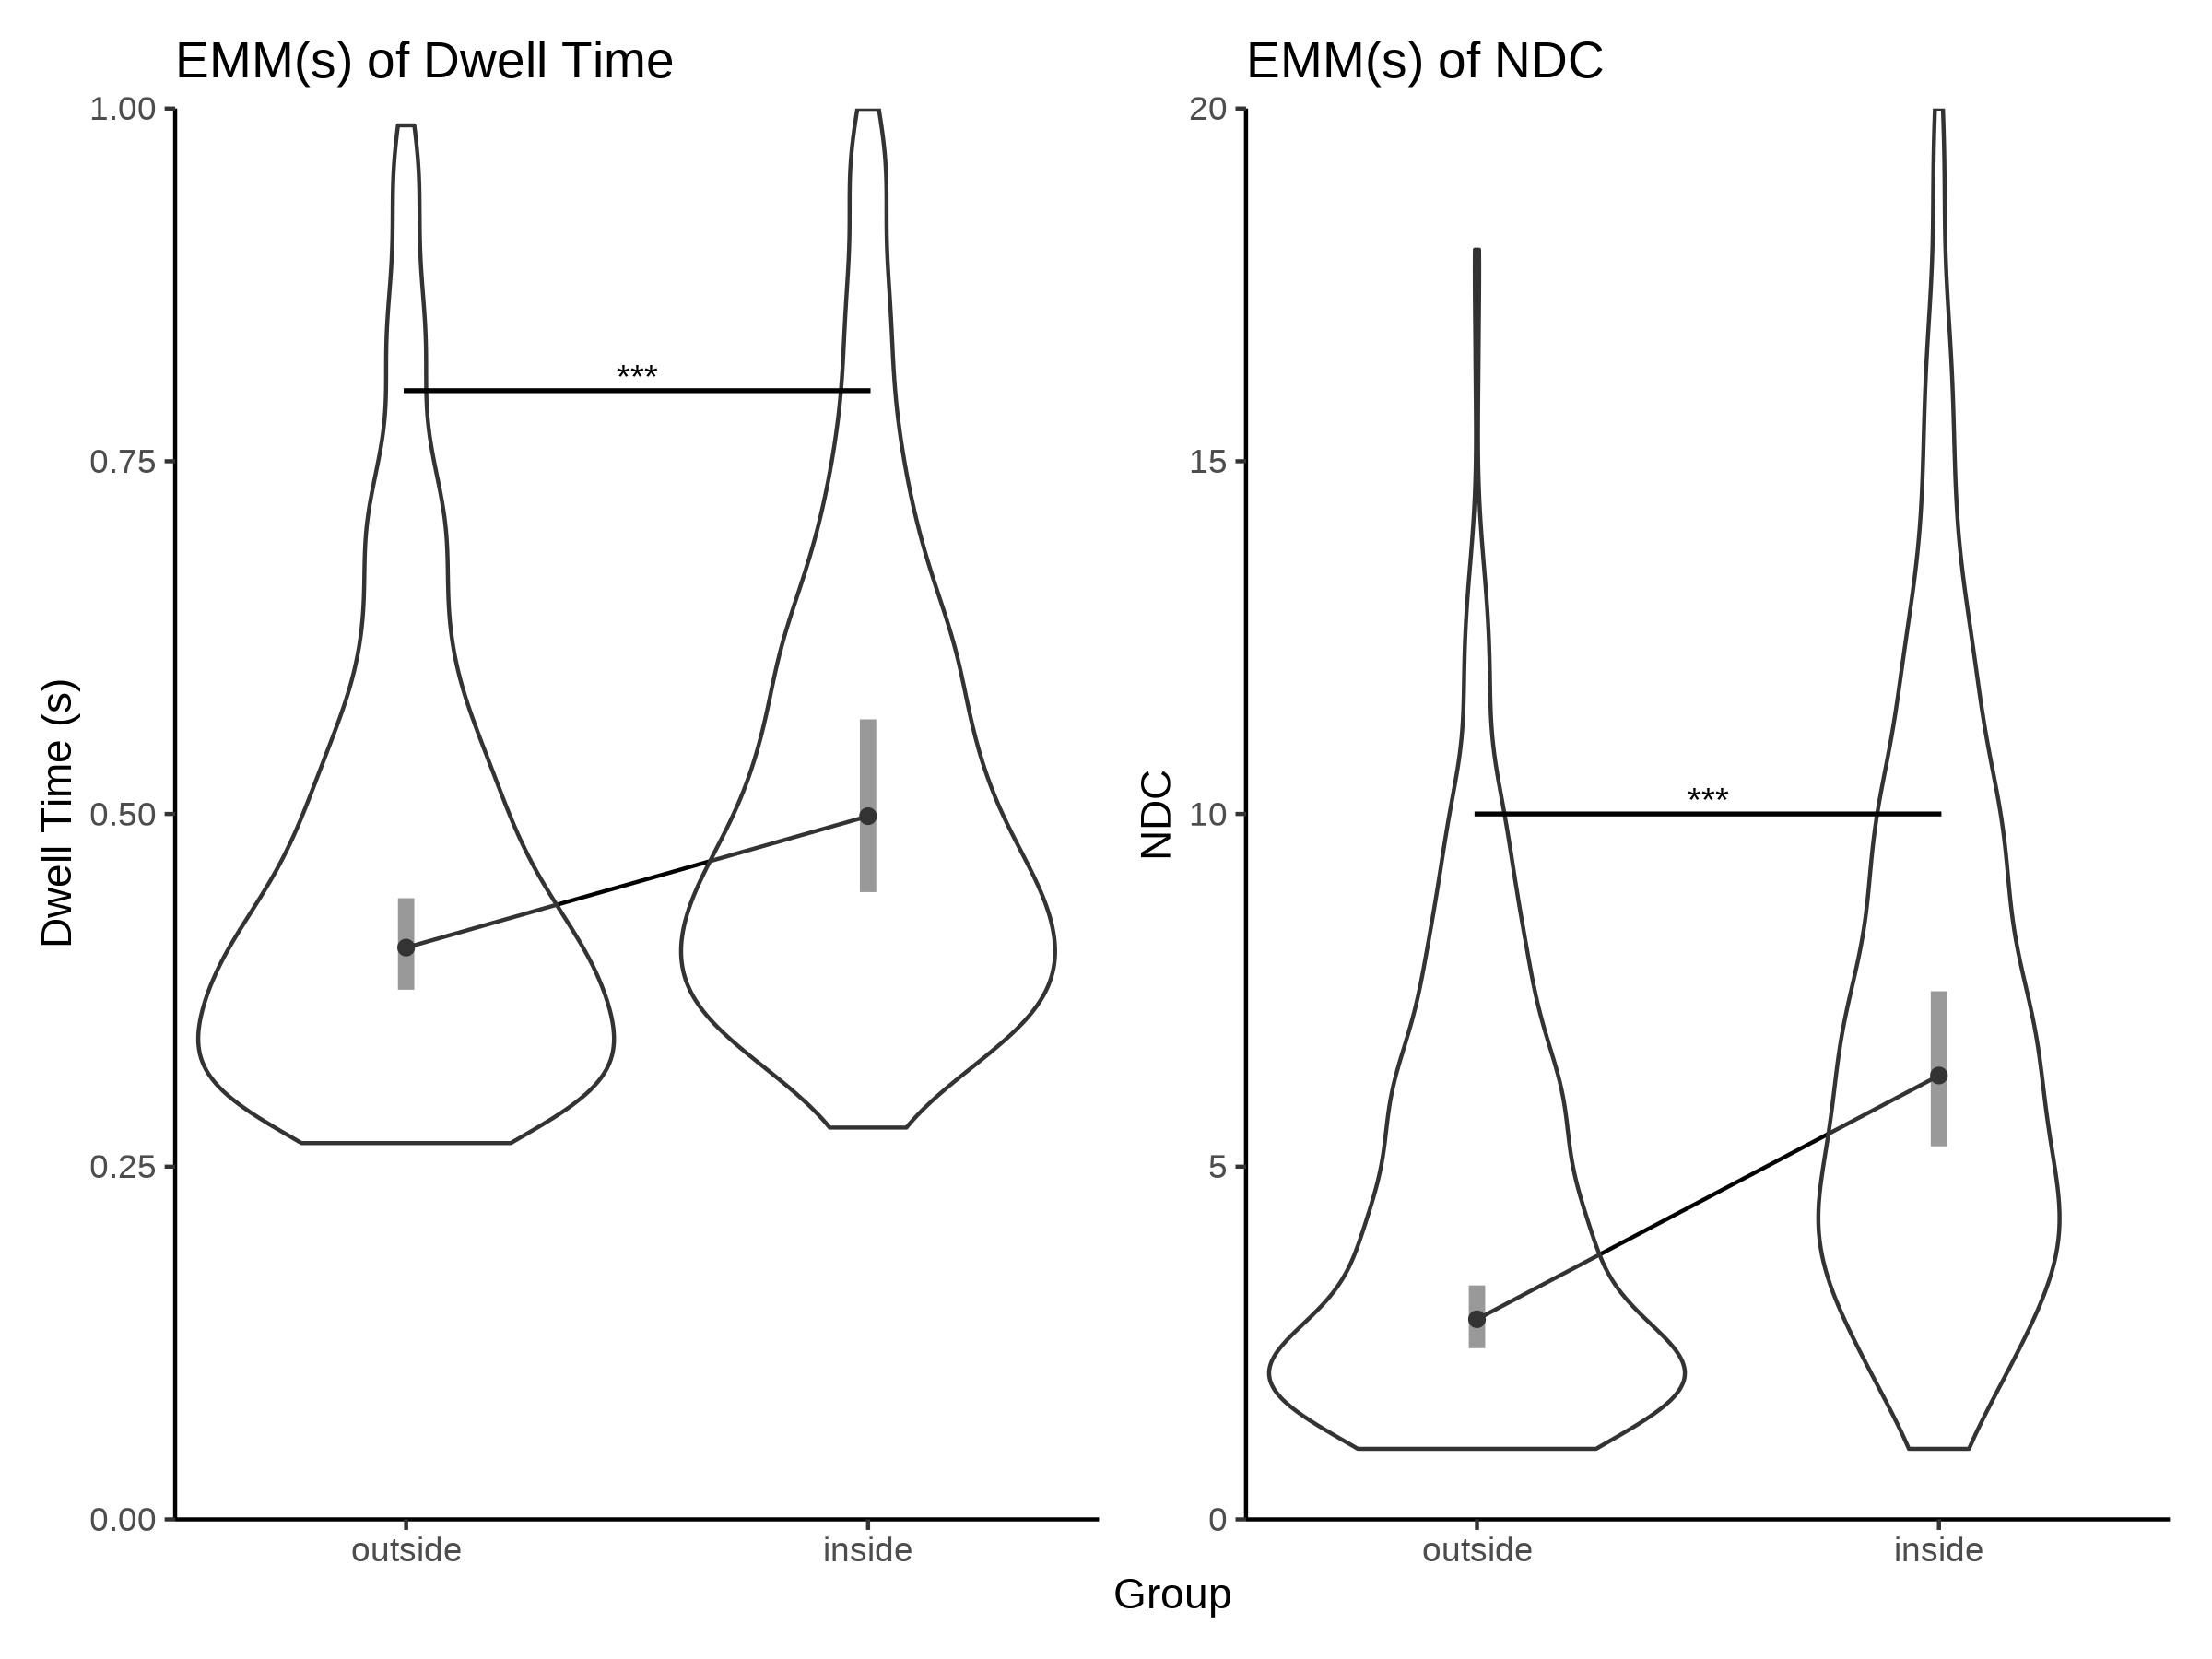

In [42]:
library(patchwork)
library(ggprism)
(dwell_time_fig + ndc_mean_fig + plot_layout(axis_titles = 'collect')) & (theme_classic() + theme(legend.position = "none"))

In [15]:
dummy_data <- expand.grid(group = unique(df$group),
                          building_location = unique(df$building_location))
mm <- model.matrix(delete.response(terms(model)), dummy_data)
dummy_data$median_clusterDuration <-  1 / drop(mm %*% fixef(model))
predvar <- diag(mm %*% vcov(model) %*% t(mm))
dummy_data <- dummy_data %>%
    mutate(
        SE = sqrt(predvar),
        SE2 = sqrt(predvar + sigma(model)^2)
    )

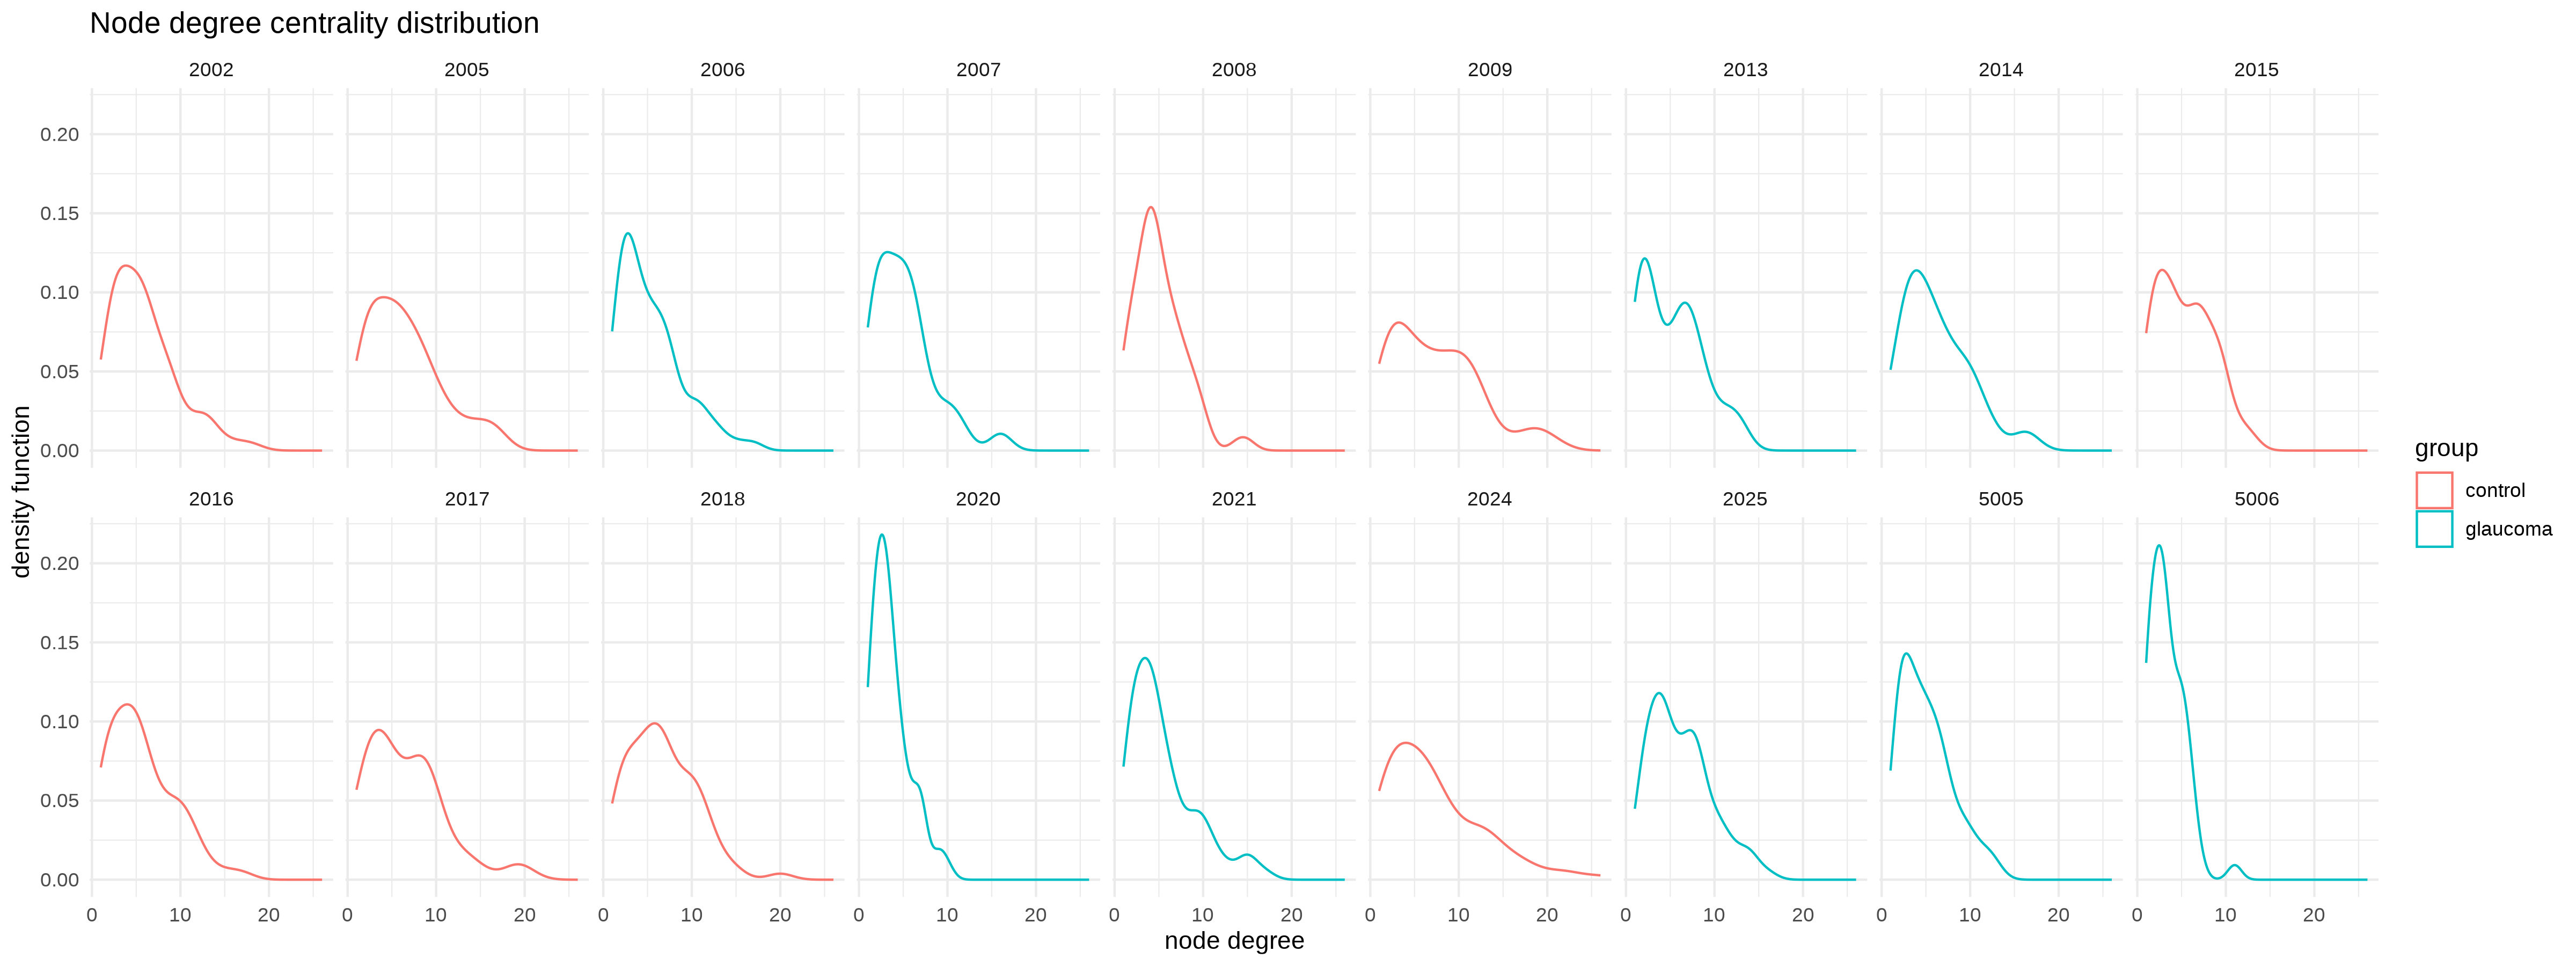

In [96]:
options(repr.plot.width=16, repr.plot.height=6, repr.plot.res = 600)
fig <- df_node |>
    ggplot(aes(x = mean_connections, group = PID, color = group)) +
      # geom_histogram(bins = 50) +
      geom_density(alpha = 0.6) +  # Adjust alpha for transparency
      facet_wrap(
          ~ factor(PID),
          ncol = 9
      ) +  # Facet by the interaction of the two factors
      theme_minimal() +
      labs(title = "Node degree centrality distribution",
           x = "node degree",
           y = "density function")
fig
#ggsave("sim_indiv_node_degree_dist.svg", fig, width = 16, height = 6, units = "in", dpi = 600)
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)

In [20]:
df_group_node <- df_node |>
    group_by(PID, building, group, building_location, connections) |>
    summarise(median_duration = median(duration)) |>
    ungroup()

`summarise()` has grouped output by 'PID', 'building', 'group', 'building_location'. You can override using the
`.groups` argument.


In [27]:
# peripheral central control

group_df_node <- df_node |> group_by(group) |> group_split()

[1] 3

In [30]:
# connections
ks.test(group_df_node[[1]] |> pull(connections), group_df_node[[2]] |> pull(connections))
ks.test(group_df_node[[1]] |> pull(connections), group_df_node[[3]] |> pull(connections))
ks.test(group_df_node[[2]] |> pull(connections), group_df_node[[3]] |> pull(connections))

Warning message in ks.test.default(pull(group_df_node[[1]], connections), pull(group_df_node[[2]], :
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  pull(group_df_node[[1]], connections) and pull(group_df_node[[2]], connections)
D = 0.070928, p-value = 2.091e-12
alternative hypothesis: two-sided


Warning message in ks.test.default(pull(group_df_node[[1]], connections), pull(group_df_node[[3]], :
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  pull(group_df_node[[1]], connections) and pull(group_df_node[[3]], connections)
D = 0.083856, p-value < 2.2e-16
alternative hypothesis: two-sided


Warning message in ks.test.default(pull(group_df_node[[2]], connections), pull(group_df_node[[3]], :
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  pull(group_df_node[[2]], connections) and pull(group_df_node[[3]], connections)
D = 0.15109, p-value < 2.2e-16
alternative hypothesis: two-sided


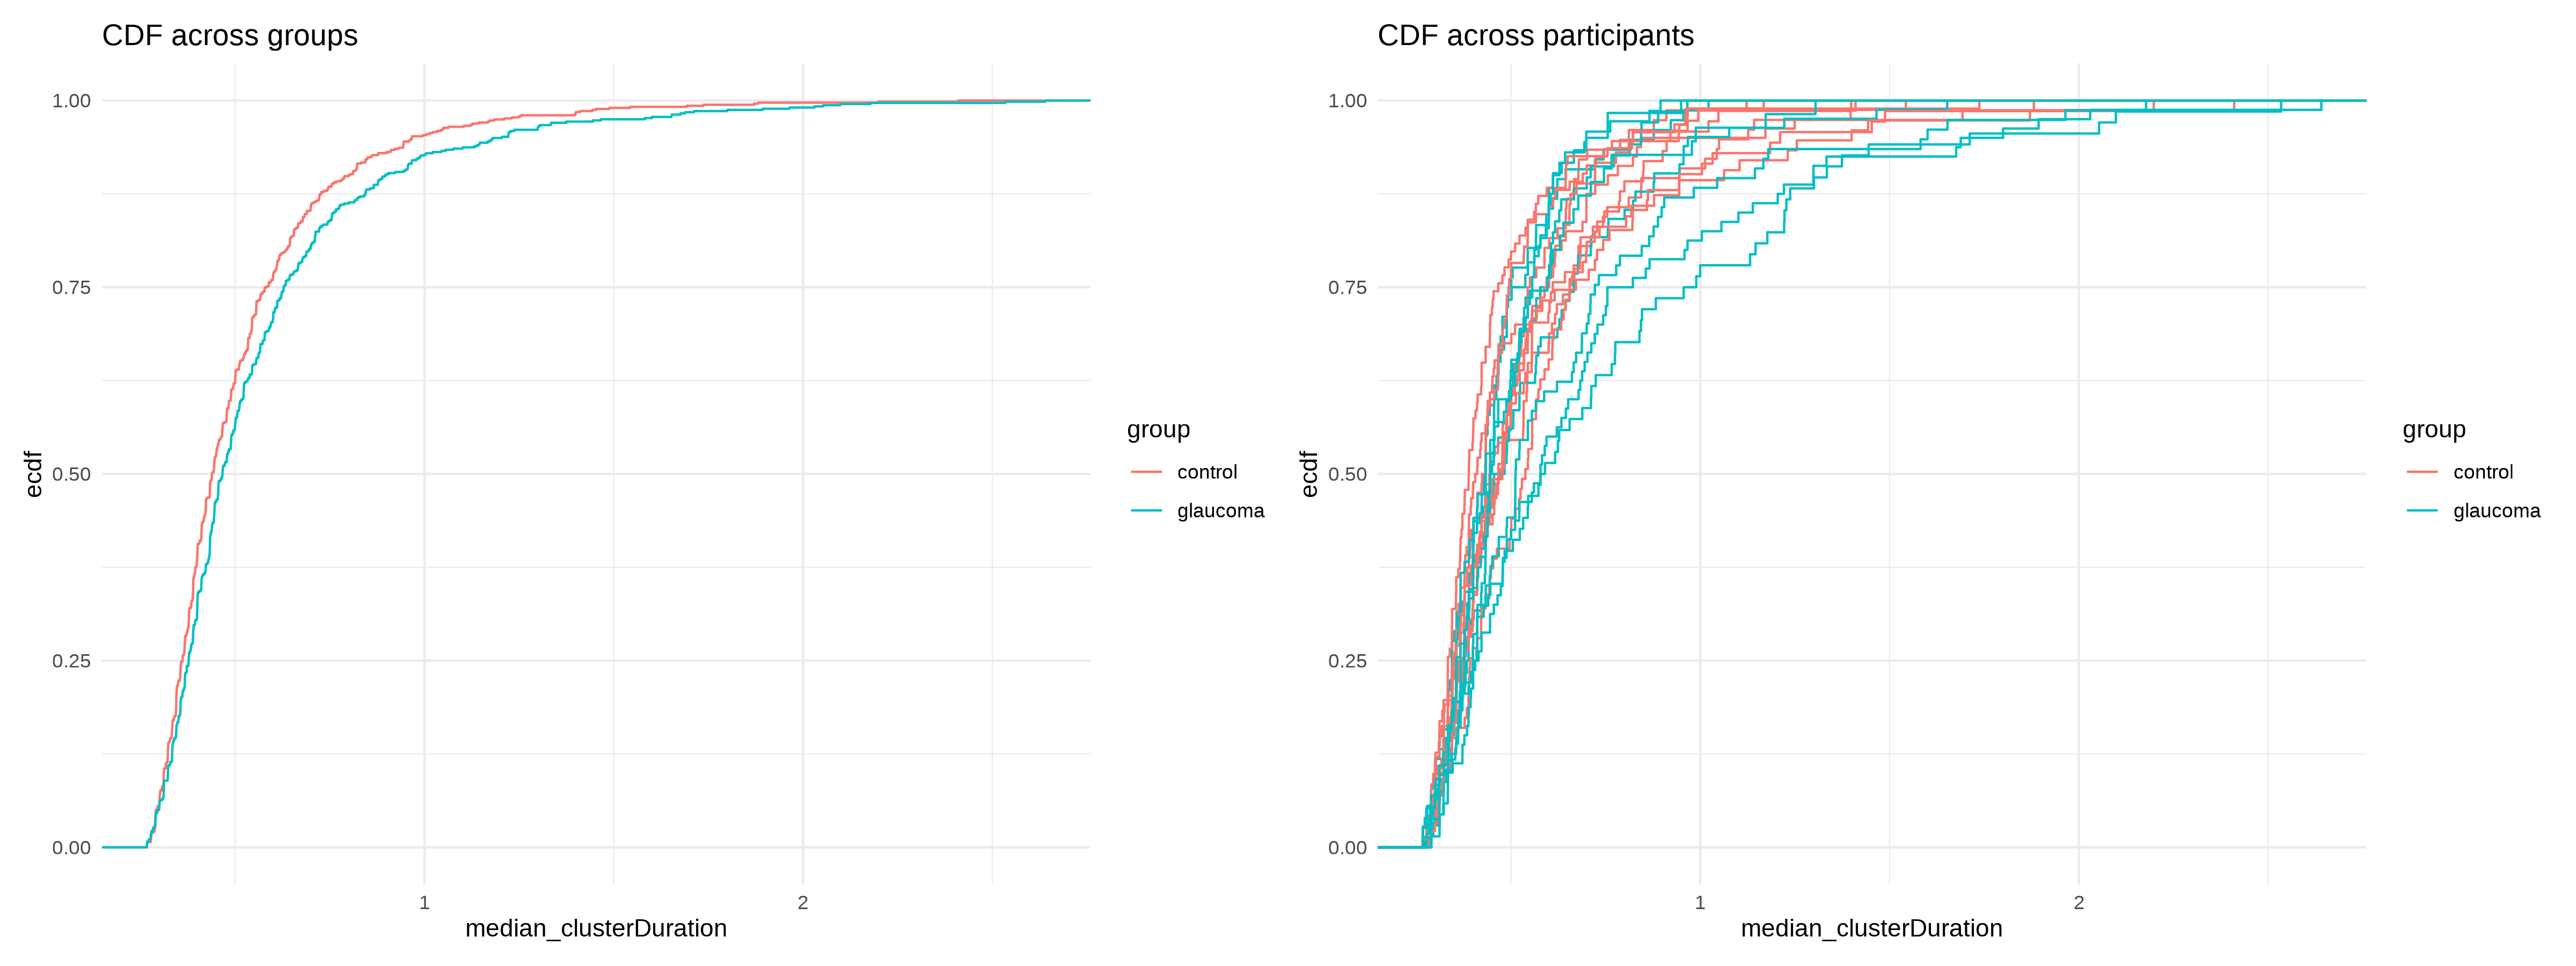

In [352]:
library(patchwork)
fig_group <- ggplot(df_combined, aes(median_clusterDuration, group = group, color = group)) +
  stat_ecdf(geom = "step") +
  labs(title = "CDF across groups") +
  theme_minimal()
fig_participants <- ggplot(df_combined, aes(median_clusterDuration, group = PID, color = group)) +
  stat_ecdf(geom = "step") +
  labs(title = "CDF across participants") + 
  theme_minimal()
options(repr.plot.width=16, repr.plot.height=6, repr.plot.res = 300)
fig_group | fig_participants
#options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)
#ggsave("group_node_degree_ecdf.svg", fig_group | fig_participants, width = 16, height = 6, units = "in", dpi = 300)

In [266]:
plot_group_cdf_with_ribbon <- function(df, value_col, individual_col, group_col = NULL,
                                       probs = c(0.05, 0.95), x_points = 200) {
  # Create x grid
  x_grid <- df %>% pull({{ value_col }}) %>% range() %>%
    (\(rng) seq(rng[1], rng[2], length.out = x_points))()

  # Compute ECDFs
  ecdf_df <- df %>%
    nest(data = -c({{ group_col }}, {{ individual_col }})) %>%
    mutate(ecdf = map(data, ~ ecdf(pull(.x, {{ value_col }})))) %>%
    crossing(x = x_grid) %>%
    mutate(y = map2_dbl(ecdf, x, ~ .x(.y))) %>%
    dplyr::select({{ group_col }}, {{ individual_col }}, x, y)

  # Summarize across individuals
  ecdf_summary <- ecdf_df %>%
    group_by({{ group_col }}, x) %>%
    summarize(
      ymin = quantile(y, probs[1]),
      ymax = quantile(y, probs[2]),
      ymed = median(y),
      .groups = "drop"
    )

  group_ecdf_df <- df %>%
      group_by({{ group_col }}) %>%
      summarize(data = list({{ value_col }}), .groups = "drop") %>%
      mutate(ecdf = map(data, ~ ecdf(.x))) %>%
      crossing(x = x_grid) %>%
      mutate(y = map2_dbl(ecdf, x, ~ .x(.y)))

  # Plot
  ggplot(ecdf_summary, aes(x = x, group = {{ group_col }}, fill = {{ group_col }}, color = {{ group_col }})) +
    geom_ribbon(aes(ymin = ymin, ymax = ymax), alpha = 0.3, color = NA) +
    geom_line(data = group_ecdf_df, aes(x = x, y = y, color = {{ group_col }}), size = 1) +
    theme_minimal() +
    labs(x = "node degree", y = "ECDF", title = "Group CDFs with Individual Variation",
         subtitle = paste0("Ribbon = ", probs[1]*100, "% to ", probs[2]*100, "% quantile of individuals")) +
    guides(fill = guide_legend(title = "Group"), color = guide_legend(title = "Group"))
}

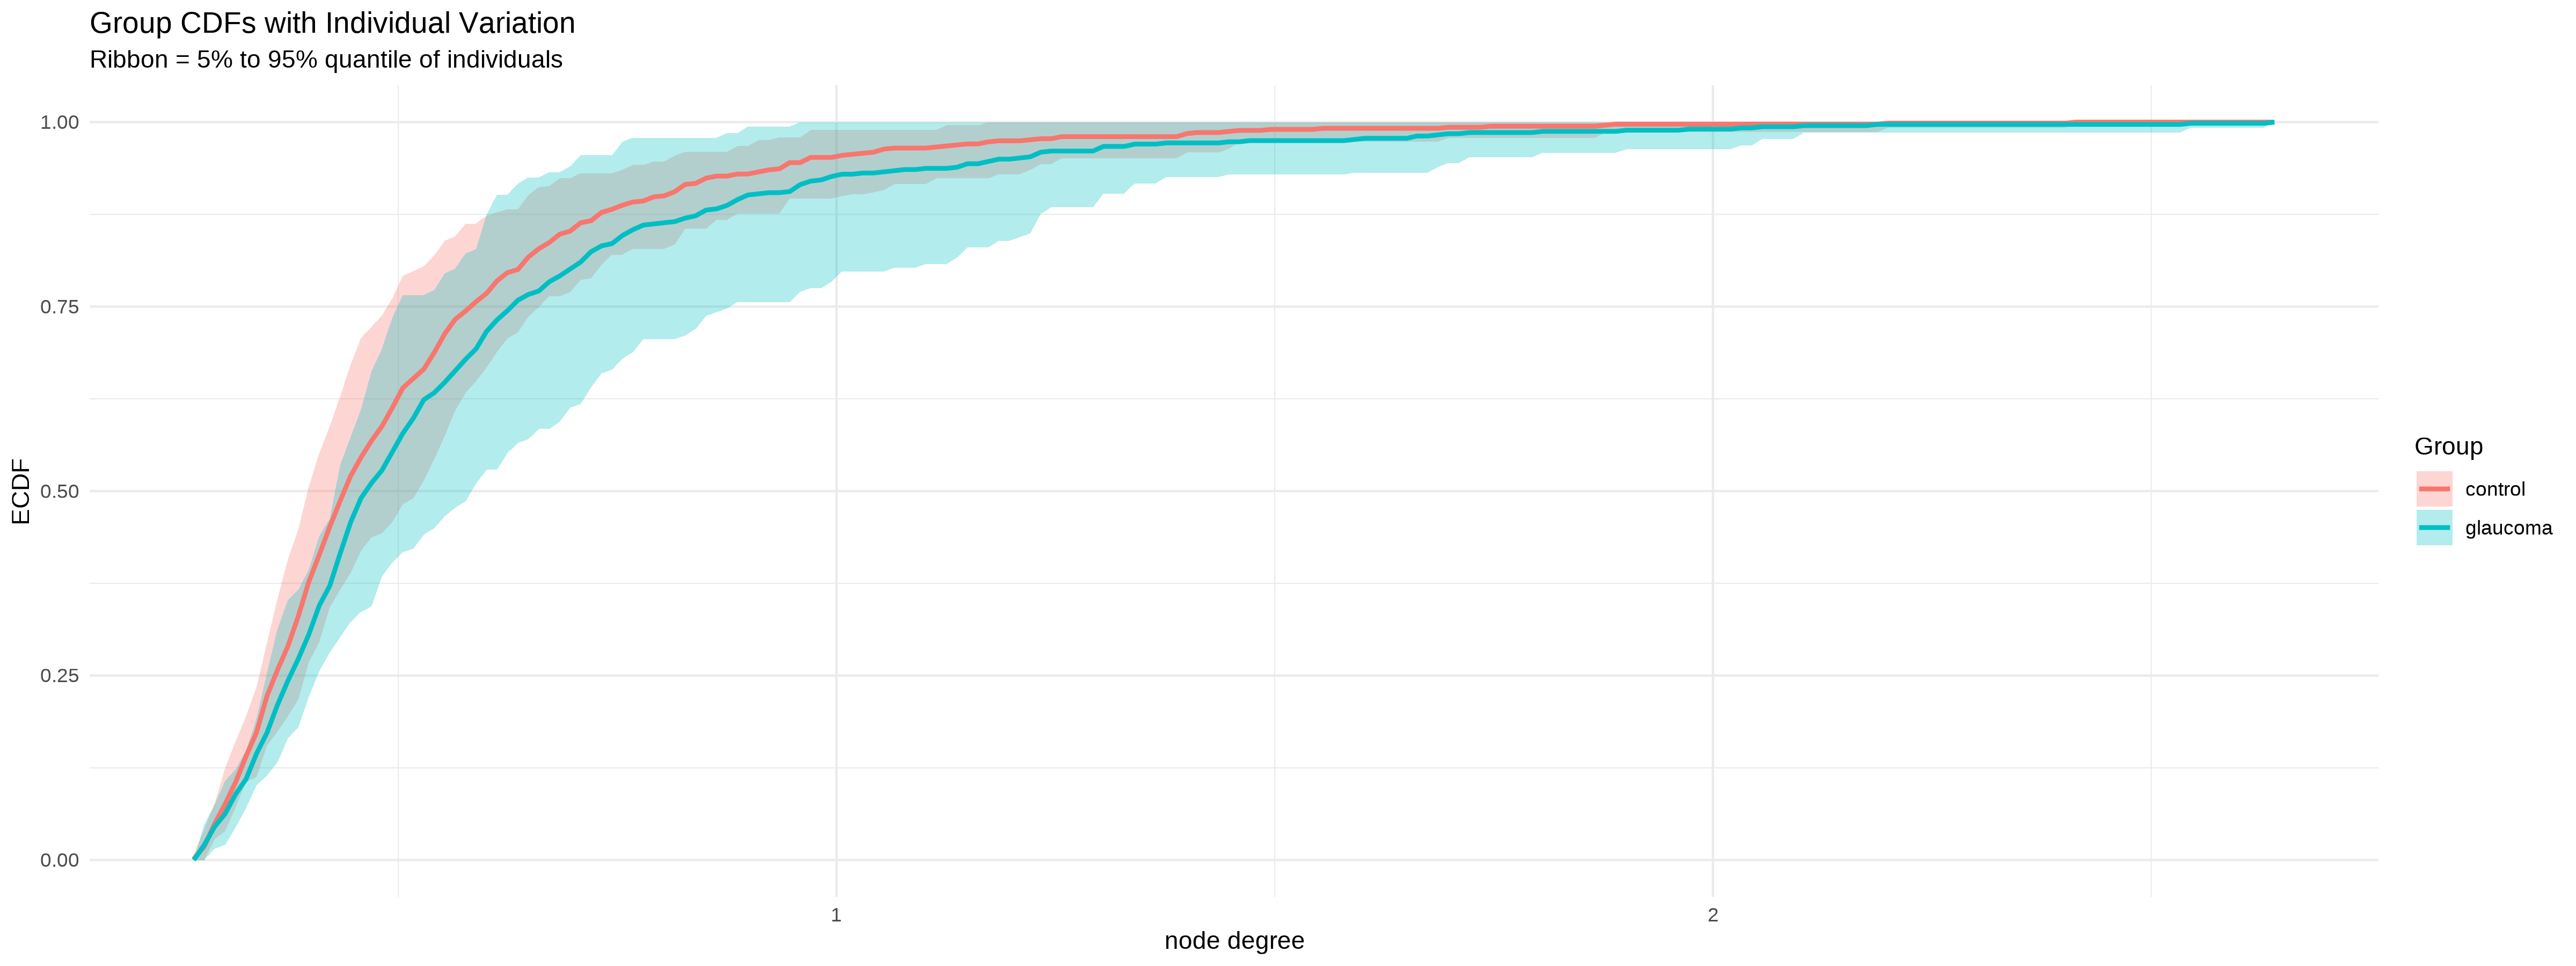

In [353]:
fig <- df_combined |> plot_group_cdf_with_ribbon(median_clusterDuration, PID, group)
fig
# ggsave("group_node_degree_ecdf.svg", fig, width = 6, height = 6, units = "in", dpi = 300)

In [22]:
df <- read_csv("graph_group_connections.csv")
df <- df |> 
    mutate(
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control")),
        hitObjectColliderName = factor(hitObjectColliderName)
    ) |>
    rename(
        group = category
    )

Rows: 1826 Columns: 4
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (2): PID, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [39]:
fig <- df |>
  ggplot(aes(x = connections, group = group, color = group)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  theme_minimal() +
  labs(title = "Node degree centrality distribution",
       x = "node degree",
       y = "density")
#ggsave("sim_node_degree_dist.svg", fig)
fig

df_node |>
    group_by(PID, building, group, building_location, connections) |>
    ungroup() |>
    filter(connections > 10) |>
    ggplot(aes(x = duration)) +
      geom_density(alpha = 0.6) +  # Adjust alpha for transparency
      xlim(0,1)+
      facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
      theme_minimal() +
      labs(title = "Density Plot (node-degree > 10)",
           x = "median cluster duration for each building (s)",
           y = "density")
ggsave("naisu_only_location_node_filter.svg", fig)

Saving 6.67 x 6.67 in image


In [64]:
df_rm_null <- df_group_node |> filter(connections > 0)

model <- glmer(connections ~  group * building_location + (1 | PID), data = df_rm_null, Gamma(link = "inverse"))

In [63]:
# Create a reference grid
ref_grid <- ref_grid(model)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ building_location)

# View results
summary(emm)
pairs(emm, adjust = "bonferroni")
pairs(emm, adjust = "tukey")

,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,4.350301,0.1925744,Inf,3.972862,4.727740
2,inside,6.887977,0.4680248,Inf,5.970666,7.805289


 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -2.54 0.311 Inf  -8.147  <.0001

Results are averaged over the levels of: group 

 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -2.54 0.311 Inf  -8.147  <.0001

Results are averaged over the levels of: group 

In [65]:
model
library(car)
Anova(model)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( inverse )
Formula: connections ~ group * building_location + (1 | PID)
   Data: df_rm_null
      AIC       BIC    logLik  deviance  df.resid 
 9238.169  9282.248 -4611.084  9222.169      1818 
Random effects:
 Groups   Name        Std.Dev.
 PID      (Intercept) 0.02747 
 Residual             0.57017 
Number of obs: 1826, groups:  PID, 24
Fixed Effects:
                         (Intercept)                          groupcentral  
                            0.237722                              0.003478  
                        groupcontrol               building_locationinside  
                           -0.024330                             -0.072348  
groupcentral:building_locationinside  groupcontrol:building_locationinside  
                           -0.017550                             -0.016438  

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
group,2.619834,2,2.698424e-01
building_location,310.818873,1,1.448236e-69
group:building_location,2.724093,2,2.561361e-01
